## 지우 EDA - 상권매출지표

# 서울 관광 상권 EDA — 추정매출-상권

**프로젝트**: 서울 관광 상권 지도  
**범위**: 추정매출-상권 데이터 (519,931행, 2020 Q1 ~ 2025 Q4, 24개 분기, 55컬럼)  
**목적**: 상권 발달 점수 산출에 필요한 매출/객단가/페르소나 인사이트 도출

## EDA 단계
1. **데이터 로드 & 인벤토리** — shape, dtype, 결측, 컬럼 구조
2. **핵심 변수 분포** — 매출/건수/객단가 (원본 + 로그변환)
3. **상권 구분별 비교** — 관광특구 vs 발달 vs 골목 vs 전통시장
4. **업종별 매출 패턴** — 어떤 업종이 어디서 잘 팔리는지
5. **페르소나 분석** — 성/연령/시간대/요일별 매출 분해
6. **시계열 트렌드** — 2020~2025 분기별 추이, 코로나 회복

>  점포-상권(폐업률·개업률)은 소희님

---
## 📦 Step 0: 환경 설정

- 라이브러리 import
- 한글 폰트 (OS 자동 감지)
- 파일 경로 설정 ⚠️ **본인 환경에 맞게 수정 필요**

In [88]:
import pandas as pd

In [89]:
"""
setup_data.py - 데이터 압축 해제 스크립트
Mac에서 만든 zip의 한글 파일명도 정상 처리
"""
import zipfile
from pathlib import Path
import shutil
import sys

def extract_with_encoding(zip_path, target):
    """Mac에서 만든 zip의 한글 파일명 깨짐 문제 해결"""
    with zipfile.ZipFile(zip_path, 'r') as z:
        for info in z.infolist():
            # __MACOSX 폴더 스킵
            if info.filename.startswith('__MACOSX'):
                continue
            
            # 파일명 인코딩 복구 시도 (cp437 → utf-8)
            try:
                filename = info.filename.encode('cp437').decode('utf-8')
            except (UnicodeDecodeError, UnicodeEncodeError):
                filename = info.filename
            
            # 디렉토리면 생성만
            if info.is_dir():
                (target / filename).mkdir(parents=True, exist_ok=True)
                continue
            
            # 파일 저장
            out_path = target / filename
            out_path.parent.mkdir(parents=True, exist_ok=True)
            with z.open(info) as src, open(out_path, 'wb') as dst:
                shutil.copyfileobj(src, dst)

def main():
    RAW_DIR = Path('data/raw')
    EXTRACT_DIR = Path('data/extracted')
    
    if not RAW_DIR.exists():
        print(f'❌ {RAW_DIR} 폴더가 없습니다.')
        sys.exit(1)
    
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    
    zip_files = sorted(RAW_DIR.glob('*.zip'))
    if not zip_files:
        print(f'⚠️  {RAW_DIR} 에 zip 파일이 없습니다.')
        sys.exit(1)
    
    print(f'📦 {len(zip_files)}개 zip 파일 처리 시작\n')
    
    extracted = 0
    skipped = 0
    
    for zip_path in zip_files:
        target = EXTRACT_DIR / zip_path.stem
        
        if target.exists() and any(target.iterdir()):
            print(f'  ⏭  {zip_path.name} (이미 풀림)')
            skipped += 1
            continue
        
        print(f'  📂 {zip_path.name}')
        target.mkdir(exist_ok=True)
        try:
            extract_with_encoding(zip_path, target)
            csv_count = len(list(target.glob('*.csv')))
            print(f'      ✅ CSV {csv_count}개 생성')
            extracted += 1
        except Exception as e:
            print(f'      ❌ 에러: {e}')
    
    print(f'\n{"="*50}')
    print(f'✅ 완료: 새로 해제 {extracted}개, 스킵 {skipped}개')
    print(f'📁 데이터 위치: {EXTRACT_DIR.resolve()}')

if __name__ == '__main__':
    main()

📦 6개 zip 파일 처리 시작

  📂 상권분석서비스(점포_상권).zip
      ✅ CSV 6개 생성
  📂 서울시 상권분석서비스(길단위인구-상권).zip
      ✅ CSV 1개 생성
  📂 서울시 상권분석서비스(상권변화지표-상권).zip
      ✅ CSV 1개 생성
  📂 서울시 상권분석서비스(상주인구-상권).zip
      ✅ CSV 1개 생성
  📂 서울시 상권분석서비스(직장인구-상권).zip
      ✅ CSV 1개 생성
  📂 서울시_상권분석서비스(추정매출+영역).zip
      ✅ CSV 7개 생성

✅ 완료: 새로 해제 6개, 스킵 0개
📁 데이터 위치: C:\final\seouldf\data\extracted


In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# seaborn 스타일을 먼저 적용 (이게 폰트를 덮어쓸 수 있어서 순서 중요!)
sns.set_style('whitegrid')

# 그 다음 한글 폰트 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 출력 옵션
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:,.2f}'.format)

print(' 환경 설정 완료')



 환경 설정 완료


In [91]:
# 프로젝트 루트 기준 상대경로 (팀원 누구든 git pull 받으면 그대로 작동)
DATA_DIR = 'data/extracted/서울시_상권분석서비스(추정매출+영역)/'

# 추정매출 6개년 파일 경로
SALES_PATHS = {
    2020: DATA_DIR + '서울시_상권분석서비스(추정매출-상권)_2020년.csv',
    2021: DATA_DIR + '서울시_상권분석서비스(추정매출-상권)_2021년.csv',
    2022: DATA_DIR + '서울시_상권분석서비스(추정매출-상권)_2022년.csv',
    2023: DATA_DIR + '서울시_상권분석서비스(추정매출-상권)_2023년.csv',
    2024: DATA_DIR + '서울시_상권분석서비스(추정매출-상권)_2024년.csv',
    2025: DATA_DIR + '서울시_상권분석서비스(추정매출-상권)_2025년.csv',
}

# 영역 파일 (상권의 자치구/행정동/좌표 정보 - merge용)
AREA_PATH = DATA_DIR + '서울시 상권분석서비스(영역-상권).csv'

# 분석 기준 분기 (최신)
LATEST_QUARTER = 20254  # 2025년 4분기

---
## Step 1: 데이터 로드 & 인벤토리

목표:
- 6개 연도 파일을 하나로 통합
- 행수, 컬럼 수, 분기 범위 확인
- 결측치/타입 검사
- 55개 컬럼을 카테고리별로 그룹화

In [92]:
import glob
import os

# 추정매출 파일 자동 탐색
pattern = DATA_DIR + '*추정매출*.csv'
sales_files = sorted(glob.glob(pattern))

print(f'총 파일: {len(sales_files)}개')
for f in sales_files:
    print(f'  {os.path.basename(f)}')

# 통합
sales_list = []
for path in sales_files:
    df = pd.read_csv(path, encoding='cp949', low_memory=False)
    sales_list.append(df)

sales = pd.concat(sales_list, ignore_index=True)
print(f'\n📦 통합 완료: {len(sales):,}행 × {len(sales.columns)}컬럼')
print(f' 메모리: {sales.memory_usage(deep=True).sum()/1024**2:.1f} MB')

# 영역 파일도 자동 탐색
area_path = glob.glob(DATA_DIR + '*영역*상권*.csv')[0]
area = pd.read_csv(area_path, encoding='cp949')
print(f'\n  영역: {len(area):,}개 상권')

총 파일: 6개
  서울시_상권분석서비스(추정매출-상권)_2020년.csv
  서울시_상권분석서비스(추정매출-상권)_2021년.csv
  서울시_상권분석서비스(추정매출-상권)_2022년.csv
  서울시_상권분석서비스(추정매출-상권)_2023년.csv
  서울시_상권분석서비스(추정매출-상권)_2024년.csv
  서울시_상권분석서비스(추정매출-상권)_2025년.csv

📦 통합 완료: 519,931행 × 55컬럼
 메모리: 365.0 MB

  영역: 1,650개 상권


In [93]:
# 데이터 모양과 타입
print(f'추정매출: {sales.shape}')
print(f'영역:    {area.shape}')

key_cols = ['기준_년분기_코드','상권_구분_코드_명','상권_코드','상권_코드_명',
            '서비스_업종_코드','서비스_업종_코드_명','당월_매출_금액','당월_매출_건수']
print(sales[key_cols].dtypes)

추정매출: (519931, 55)
영역:    (1650, 11)
기준_년분기_코드       int64
상권_구분_코드_명     object
상권_코드           int64
상권_코드_명        object
서비스_업종_코드      object
서비스_업종_코드_명    object
당월_매출_금액        int64
당월_매출_건수        int64
dtype: object


In [94]:
# 결측치 검사
miss = sales.isnull().sum()
miss = miss[miss > 0]

In [95]:
# 시간/공간 범위
print(f' 분기 범위: {sales["기준_년분기_코드"].min()} ~ {sales["기준_년분기_코드"].max()}')
print(f' 분기 수:   {sales["기준_년분기_코드"].nunique()}개')
print(f'\n 상권 수:   {sales["상권_코드"].nunique():,}개')
print(f'  업종 수:   {sales["서비스_업종_코드"].nunique()}개')

# 상권 구분 분포
print(f'\n 상권 구분별 ( {LATEST_QUARTER} 분기 기준)')
print(sales[sales['기준_년분기_코드']==LATEST_QUARTER]
      .drop_duplicates('상권_코드')['상권_구분_코드_명'].value_counts())

 분기 범위: 20201 ~ 20254
 분기 수:   24개

 상권 수:   1,603개
  업종 수:   63개

 상권 구분별 ( 20254 분기 기준)
상권_구분_코드_명
골목상권    1030
전통시장     280
발달상권     249
관광특구       6
Name: count, dtype: int64


In [96]:
# 55개 컬럼을 카테고리별로 정리
amount_cols = [c for c in sales.columns if '매출_금액' in c]
count_cols = [c for c in sales.columns if '매출_건수' in c]

요일_금액 = [c for c in amount_cols if any(d in c for d in ['월요일','화요일','수요일','목요일','금요일','토요일','일요일','주중','주말'])]
시간_금액 = [c for c in amount_cols if '시간대' in c]
성별_금액 = [c for c in amount_cols if '남성' in c or '여성' in c]
연령_금액 = [c for c in amount_cols if '연령대' in c]

print(f' 매출금액 컬럼: {len(amount_cols)}개')
print(f'   - 기본:    당월_매출_금액')
print(f'   - 요일별:  {len(요일_금액)}개 (월~일 + 주중/주말)')
print(f'   - 시간대:  {len(시간_금액)}개 (6구간)')
print(f'   - 성별:    {len(성별_금액)}개')
print(f'   - 연령대:  {len(연령_금액)}개 (10~60+)')
print(f'\n 매출건수 컬럼: {len(count_cols)}개 (금액과 동일 구조)')

 매출금액 컬럼: 24개
   - 기본:    당월_매출_금액
   - 요일별:  9개 (월~일 + 주중/주말)
   - 시간대:  6개 (6구간)
   - 성별:    2개
   - 연령대:  6개 (10~60+)

 매출건수 컬럼: 24개 (금액과 동일 구조)


###  Step 1 인사이트
- 결측치/타입 문제 없음 → 전처리 없음
- 상권×업종×분기 단위로 약 52만 행
- **각 행이 하나의 페르소나 분석 단위** (성/연령/시간/요일 모두 분해되어 있음)

---
##  Step 2: 핵심 변수 분포 분석

목표:
- 매출금액/건수/객단가 기초통계
- 분포 모양 시각화 (원본 vs 로그변환)
- 정규화 방법 결정

In [97]:
# 객단가 컬럼 추가
sales['객단가'] = sales['당월_매출_금액'] / sales['당월_매출_건수'].replace(0, np.nan)

# 핵심 변수 기초통계
sales[['당월_매출_금액', '당월_매출_건수', '객단가']].describe(
    percentiles=[.01, .25, .5, .75, .95, .99]
)

,당월_매출_금액,당월_매출_건수,객단가
count,"519,931.00","519,931.00","519,931.00"
mean,"1,001,650,301.61","34,299.78","108,450.75"
std,"9,659,729,281.23","160,594.85","471,596.11"
min,31.00,1.00,9.67
1%,"1,054,123.00",15.00,"4,698.07"
25%,"44,074,782.50",799.00,"14,931.07"
50%,"166,349,258.00","4,237.00","33,128.27"
75%,"596,072,470.00","21,933.00","91,287.40"
95%,"3,335,149,457.00","148,021.50","400,505.23"
99%,"11,748,000,000.00","428,643.30","1,065,273.73"


In [98]:
# 평균/중앙값 비율 (분포의 치우침 정도)
print('평균 ÷ 중앙값 비율 (1에 가까울수록 대칭, >2이면 강한 우편향)')
for col in ['당월_매출_금액','당월_매출_건수','객단가']:
    m, med = sales[col].mean(), sales[col].median()
    print(f'  {col}: {m/med:.1f}배')

평균 ÷ 중앙값 비율 (1에 가까울수록 대칭, >2이면 강한 우편향)
  당월_매출_금액: 6.0배
  당월_매출_건수: 8.1배
  객단가: 3.3배


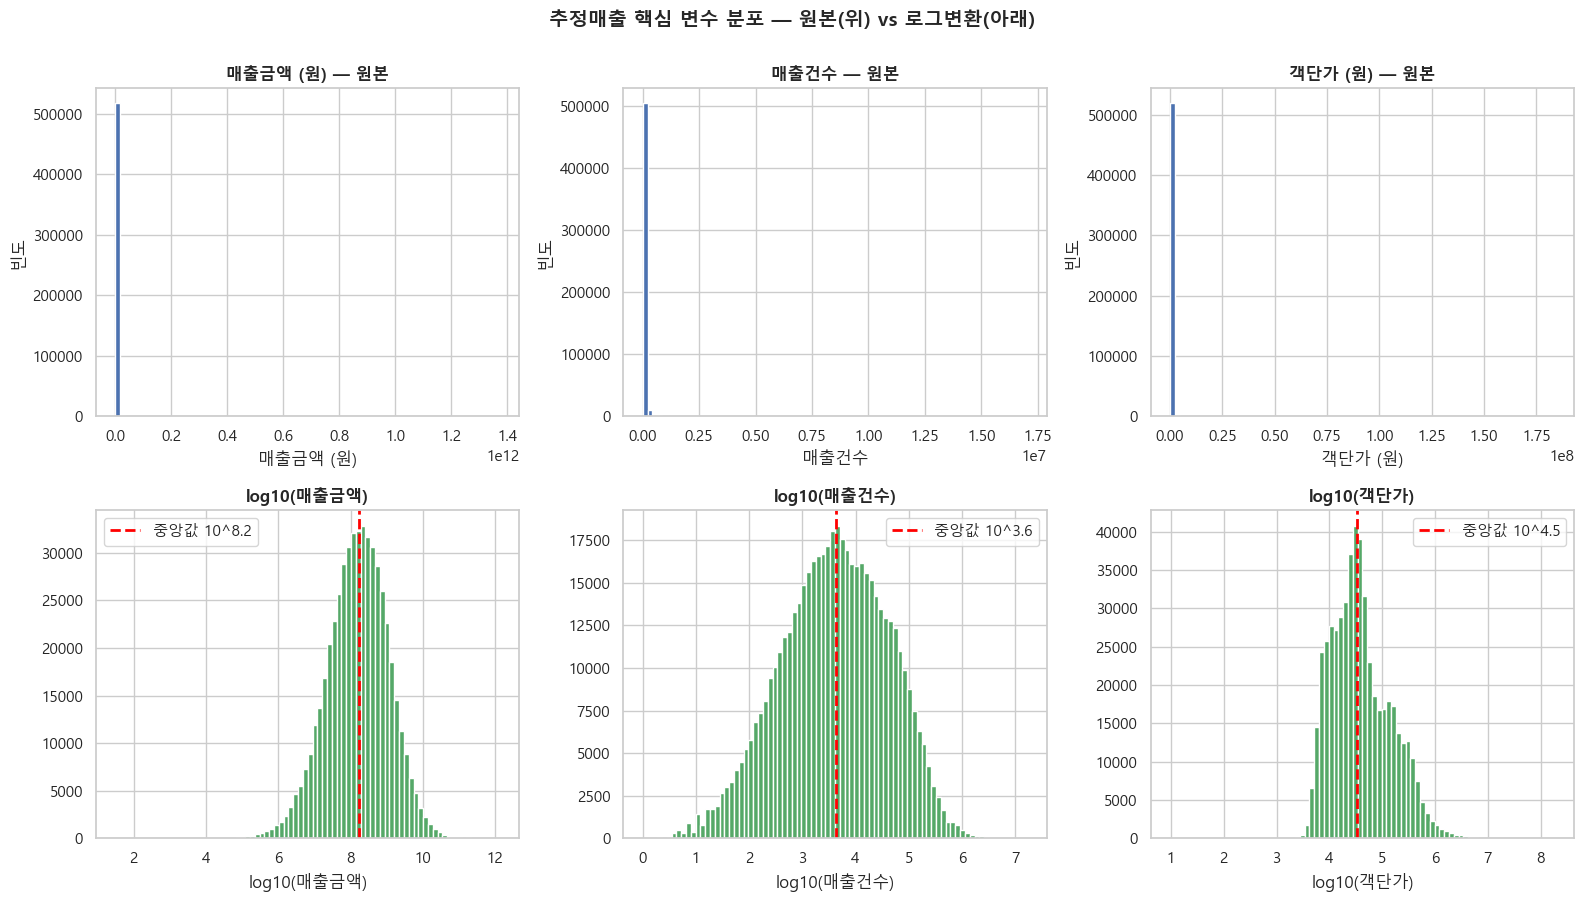

In [99]:
# 분포 시각화: 원본(위) vs 로그변환(아래)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 행 1: 원본
for ax, (col, label) in zip(axes[0], [
    ('당월_매출_금액', '매출금액 (원)'),
    ('당월_매출_건수', '매출건수'),
    ('객단가', '객단가 (원)'),
]):
    ax.hist(sales[col].dropna(), bins=80, color='#4C72B0', edgecolor='white')
    ax.set_title(f'{label} — 원본', fontsize=12, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('빈도')
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

# 행 2: 로그 변환
for ax, (col, label) in zip(axes[1], [
    ('당월_매출_금액', 'log10(매출금액)'),
    ('당월_매출_건수', 'log10(매출건수)'),
    ('객단가', 'log10(객단가)'),
]):
    log_data = np.log10(sales[col].dropna().clip(lower=1))
    ax.hist(log_data, bins=80, color='#55A868', edgecolor='white')
    ax.axvline(log_data.median(), color='red', linestyle='--', linewidth=2,
               label=f'중앙값 10^{log_data.median():.1f}')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel(label)
    ax.legend()

plt.suptitle('추정매출 핵심 변수 분포 — 원본(위) vs 로그변환(아래)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

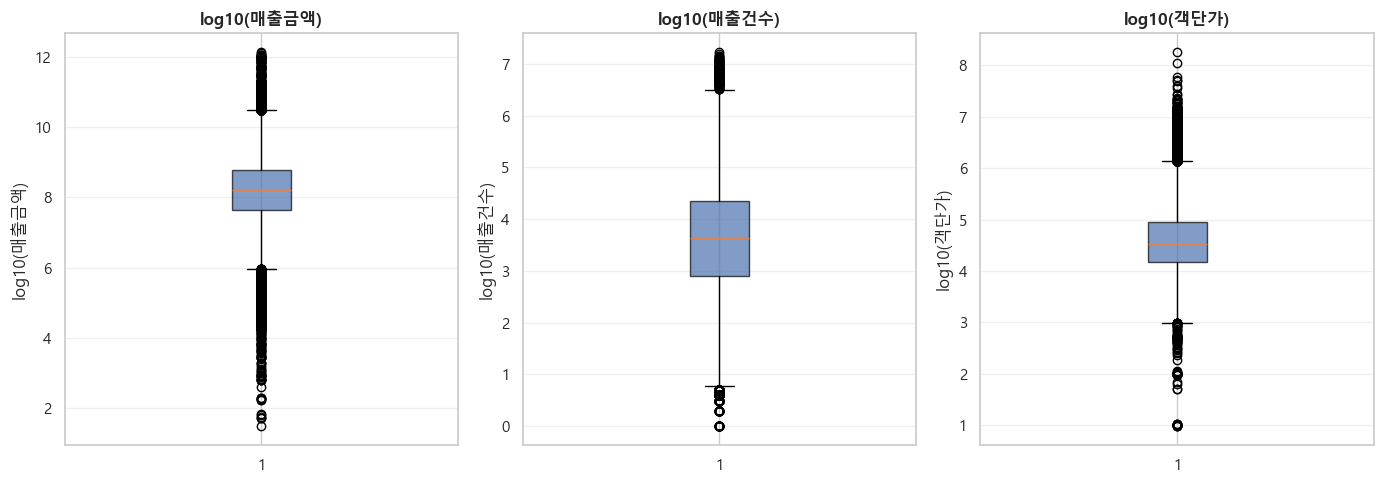

In [100]:
# 박스플롯 (로그 스케일)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (col, label) in zip(axes, [
    ('당월_매출_금액', '매출금액'),
    ('당월_매출_건수', '매출건수'),
    ('객단가', '객단가'),
]):
    log_data = np.log10(sales[col].dropna().clip(lower=1))
    ax.boxplot(log_data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#4C72B0', alpha=0.7))
    ax.set_title(f'log10({label})', fontweight='bold')
    ax.set_ylabel(f'log10({label})')
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [101]:
# 왜도 (정규분포 정도) - -0.5~+0.5면 거의 정규
print('로그 변환 후 왜도 (skewness)')
print('기준: -0.5 ~ +0.5 → 정규분포에 가까움\n')
for col in ['당월_매출_금액','당월_매출_건수','객단가']:
    log_d = np.log10(sales[col].dropna().clip(lower=1))
    skew = log_d.skew()
    상태 = ' 정규에 가까움' if abs(skew) < 0.5 else '🟡 약간 치우침'
    print(f'  {col}: 왜도={skew:+.2f}  {상태}')

로그 변환 후 왜도 (skewness)
기준: -0.5 ~ +0.5 → 정규분포에 가까움

  당월_매출_금액: 왜도=-0.25   정규에 가까움
  당월_매출_건수: 왜도=-0.19   정규에 가까움
  객단가: 왜도=+0.56  🟡 약간 치우침


### Step 2 인사이트
- 원본 분포는 극단적 우편향 (long-tail) → 그대로 못 씀
- **로그 변환** 후 정규분포에 매우 근접 (왜도 절댓값 < 0.5)
- → **상권 발달 점수에서 매출 변수는 `log10(매출)` 후 min-max 정규화 사용**
- 메모: 

---
## Step 3: 상권 구분별 비교

목표:
- 영역 파일을 merge해서 자치구 정보 결합
- 상권 단위로 매출 집계
- **관광특구 / 발달상권 / 골목상권 / 전통시장** 4가지 그룹 비교
- 프로젝트의 핵심 질문: "골목 vs 일반 상권 불균형" 첫 정량 증거

In [102]:
# 영역 정보 merge
sales_area = sales.merge(
    area[['상권_코드','자치구_코드_명','행정동_코드_명','엑스좌표_값','와이좌표_값']],
    on='상권_코드', how='left'
)
print(f'merge 후: {sales_area.shape}')
print(f'결측 자치구: {sales_area["자치구_코드_명"].isna().sum()}')

merge 후: (519931, 60)
결측 자치구: 0


In [103]:
# 최신 분기로 필터 후 상권 단위 집계
latest = sales_area[sales_area['기준_년분기_코드']==LATEST_QUARTER]

상권집계 = latest.groupby(
    ['상권_코드','상권_코드_명','상권_구분_코드_명','자치구_코드_명']
).agg(
    총매출=('당월_매출_금액','sum'),
    총건수=('당월_매출_건수','sum'),
    업종수=('서비스_업종_코드','nunique'),
).reset_index()

상권집계['객단가'] = 상권집계['총매출'] / 상권집계['총건수']
상권집계['log_매출'] = np.log10(상권집계['총매출'].clip(lower=1))
상권집계['총매출_억'] = (상권집계['총매출']/1e8).round(1)

print(f'분석 대상 상권: {len(상권집계):,}개')
상권집계.head()

분석 대상 상권: 1,565개


,상권_코드,상권_코드_명,상권_구분_코드_명,자치구_코드_명,총매출,총건수,업종수,객단가,log_매출,총매출_억
0,3001491,이태원 관광특구,관광특구,용산구,96748250708,3137664,33,"30,834.48",10.99,967.50
1,3001492,명동 남대문 북창동 다동 무교동 관광특구,관광특구,중구,537829815743,15760017,53,"34,126.22",11.73,"5,378.30"
2,3001493,동대문패션타운 관광특구,관광특구,중구,151636997858,4447433,39,"34,095.40",11.18,"1,516.40"
3,3001494,종로?청계 관광특구,관광특구,종로구,263865637195,6909787,53,"38,187.23",11.42,"2,638.70"
4,3001495,잠실 관광특구,관광특구,송파구,380932087468,13411055,42,"28,404.33",11.58,"3,809.30"


In [104]:
# 상권 구분별 요약 통계
구분통계 = 상권집계.groupby('상권_구분_코드_명').agg(
    상권수=('상권_코드','count'),
    평균매출=('총매출','mean'),
    중앙매출=('총매출','median'),
    평균객단가=('객단가','mean'),
    평균업종수=('업종수','mean'),
)
구분통계['평균매출_억'] = (구분통계['평균매출']/1e8).round(1)
구분통계['중앙매출_억'] = (구분통계['중앙매출']/1e8).round(1)
구분통계['평균객단가'] = 구분통계['평균객단가'].round(0)
구분통계['평균업종수'] = 구분통계['평균업종수'].round(1)
구분통계 = 구분통계.reindex(['관광특구','발달상권','전통시장','골목상권'])
구분통계[['상권수','평균매출_억','중앙매출_억','평균객단가','평균업종수']]

,상권수,평균매출_억,중앙매출_억,평균객단가,평균업종수
상권_구분_코드_명,,,,,
관광특구,6,"2,570.60","2,077.50","33,071.00",41.30
발달상권,249,599.60,348.40,"38,682.00",29.10
전통시장,280,138.00,46.90,"39,479.00",11.30
골목상권,1030,39.80,19.80,"42,542.00",10.40


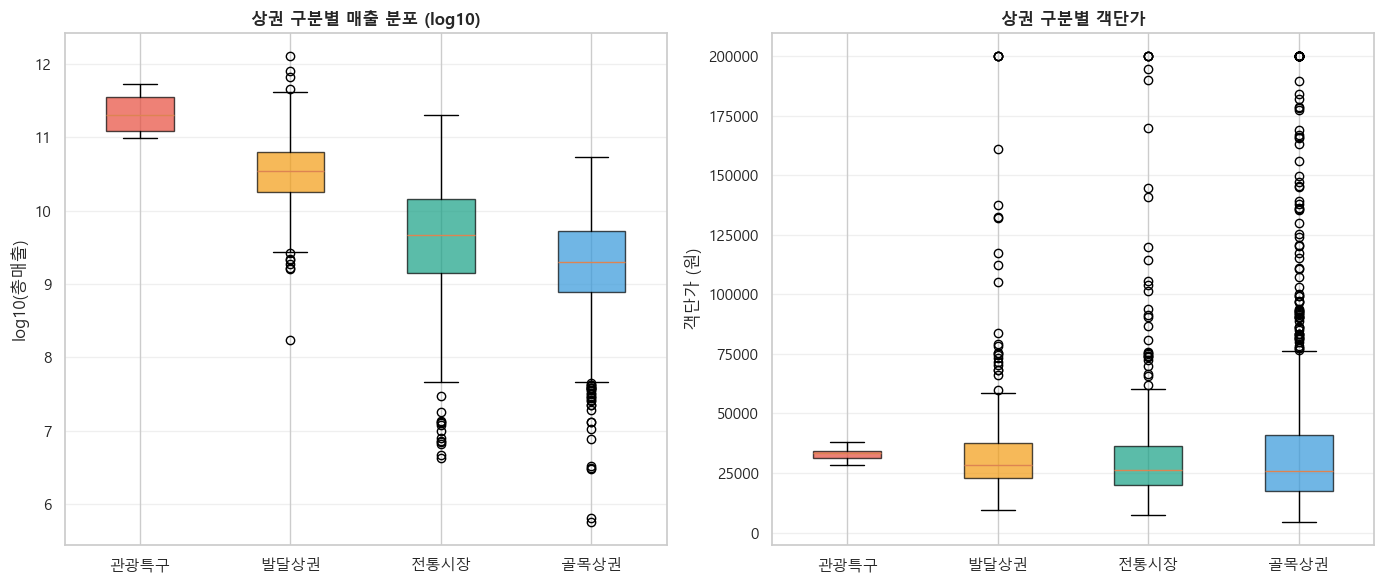

In [105]:
# 박스플롯: 상권 구분별 매출 vs 객단가
순서 = ['관광특구','발달상권','전통시장','골목상권']
colors = ['#E74C3C','#F39C12','#16A085','#3498DB']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (1) 매출 분포 (로그)
data1 = [상권집계[상권집계['상권_구분_코드_명']==g]['log_매출'].values for g in 순서]
bp1 = axes[0].boxplot(data1, labels=순서, patch_artist=True)
for patch, c in zip(bp1['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[0].set_title('상권 구분별 매출 분포 (log10)', fontweight='bold')
axes[0].set_ylabel('log10(총매출)')
axes[0].grid(axis='y', alpha=0.3)

# (2) 객단가 (200,000원 캡 - 이상치 가시성 향상)
data2 = [상권집계[상권집계['상권_구분_코드_명']==g]['객단가'].clip(upper=200000).values for g in 순서]
bp2 = axes[1].boxplot(data2, labels=순서, patch_artist=True)
for patch, c in zip(bp2['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1].set_title('상권 구분별 객단가', fontweight='bold')
axes[1].set_ylabel('객단가 (원)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [106]:
# 매출 TOP 20 상권
top20 = 상권집계.nlargest(20, '총매출')[
    ['상권_코드_명','상권_구분_코드_명','자치구_코드_명','총매출_억','업종수']
]
top20

,상권_코드_명,상권_구분_코드_명,자치구_코드_명,총매출_억,업종수
1188,노량진역(노량진),발달상권,동작구,"12,616.30",37
1166,가산디지털단지,발달상권,금천구,"8,043.80",51
1075,용산전자상가(용산역),발달상권,용산구,"6,689.90",32
1,명동 남대문 북창동 다동 무교동 관광특구,관광특구,중구,"5,378.30",53
1266,가락시장,발달상권,송파구,"4,592.10",10
1224,강남역,발달상권,서초구,"4,187.00",49
4,잠실 관광특구,관광특구,송파구,"3,809.30",42
1044,종로3가역,발달상권,종로구,"3,313.20",44
1262,잠실역,발달상권,송파구,"3,219.90",34
3,종로?청계 관광특구,관광특구,종로구,"2,638.70",53


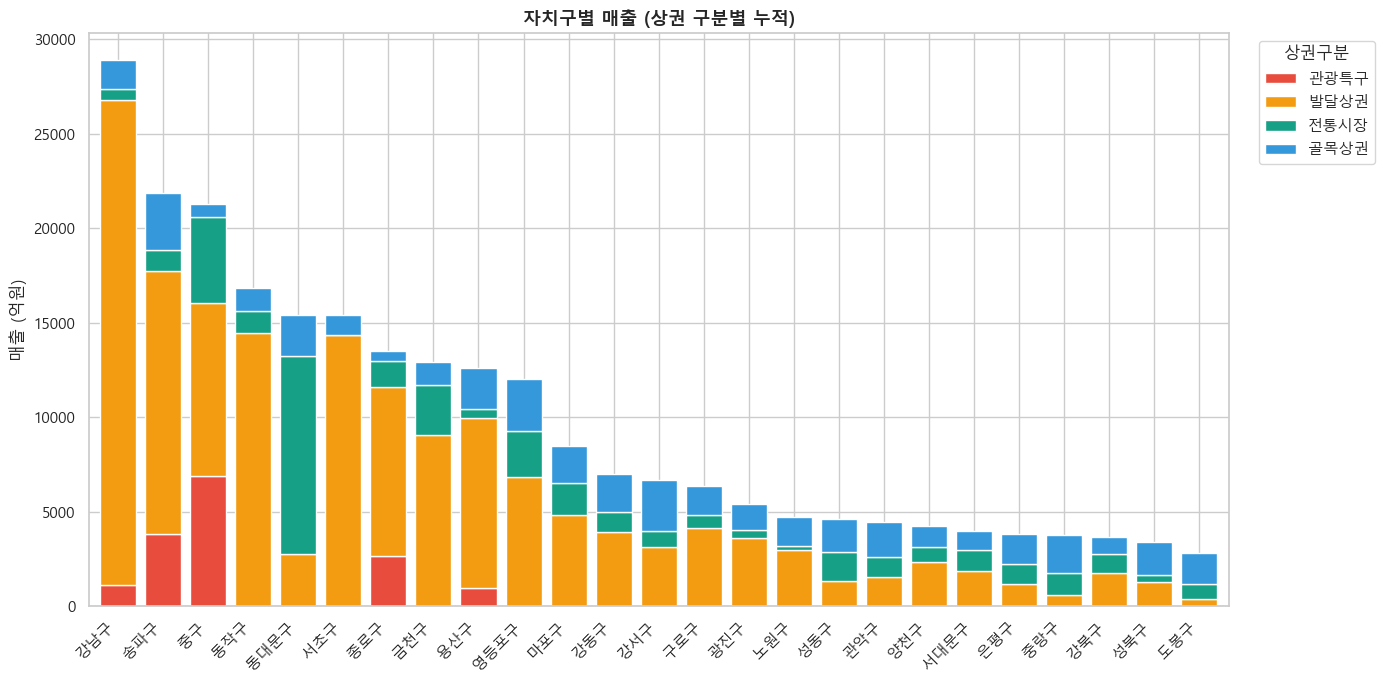

In [107]:
# 자치구별 총매출 + 상권 구분 분포
구별 = 상권집계.groupby(['자치구_코드_명','상권_구분_코드_명'])['총매출'].sum().unstack(fill_value=0)/1e8
구별['합계'] = 구별.sum(axis=1)
구별 = 구별.sort_values('합계', ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
구별_plot = 구별.drop('합계', axis=1)
구별_plot = 구별_plot[[c for c in 순서 if c in 구별_plot.columns]]
구별_plot.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.8)
ax.set_title('자치구별 매출 (상권 구분별 누적)', fontweight='bold', fontsize=13)
ax.set_ylabel('매출 (억원)')
ax.set_xlabel('')
ax.legend(title='상권구분', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 💡 Step 3 인사이트
- 관광특구가 평균 매출은 가장 높지만 **상권 수가 6개로 매우 적음** → 영향력 vs 면적 trade-off
- 골목상권 1,000여 개의 매출 분포와 발달상권 분포 비교
- 자치구별 매출 편차 → 어떤 구가 관광 매출 강자인지
- 메모: 

---
##  Step 4: 업종별 매출 패턴

목표:
- 100개 업종 중 매출 상위 업종 식별
- 어떤 업종이 어떤 상권 구분에서 강한지
- "관광객이 무엇을 사는지" 첫 단서

In [108]:
# 업종별 총매출 (최신 분기)
업종집계 = latest.groupby(['서비스_업종_코드','서비스_업종_코드_명']).agg(
    총매출=('당월_매출_금액','sum'),
    총건수=('당월_매출_건수','sum'),
    상권수=('상권_코드','nunique'),
).reset_index()
업종집계['객단가'] = 업종집계['총매출']/업종집계['총건수']
업종집계['매출_억'] = (업종집계['총매출']/1e8).round(1)
업종집계 = 업종집계.sort_values('총매출', ascending=False)
print(f'업종 수: {len(업종집계)}')
업종집계.head(10)

업종 수: 62


,서비스_업종_코드,서비스_업종_코드_명,총매출,총건수,상권수,객단가,매출_억
0,CS100001,한식음식점,3985898301921,97348712,1406,"40,944.54","39,859.00"
40,CS300011,일반의류,2132212624743,29900054,850,"71,311.33","21,322.10"
14,CS200006,일반의원,1787685318222,32891128,518,"54,351.60","17,876.90"
45,CS300018,의약품,1426634468592,58776059,583,"24,272.37","14,266.30"
37,CS300008,수산물판매,1400689731246,21052006,130,"66,534.74","14,006.90"
38,CS300009,청과상,1281305234493,49080474,274,"26,106.21","12,813.10"
39,CS300010,반찬가게,856226080781,34798223,400,"24,605.45","8,562.30"
31,CS300001,슈퍼마켓,849778983467,74225863,888,"11,448.56","8,497.80"
36,CS300007,육류판매,807736979652,14832645,405,"54,456.71","8,077.40"
32,CS300002,편의점,806130121145,110658092,671,"7,284.87","8,061.30"


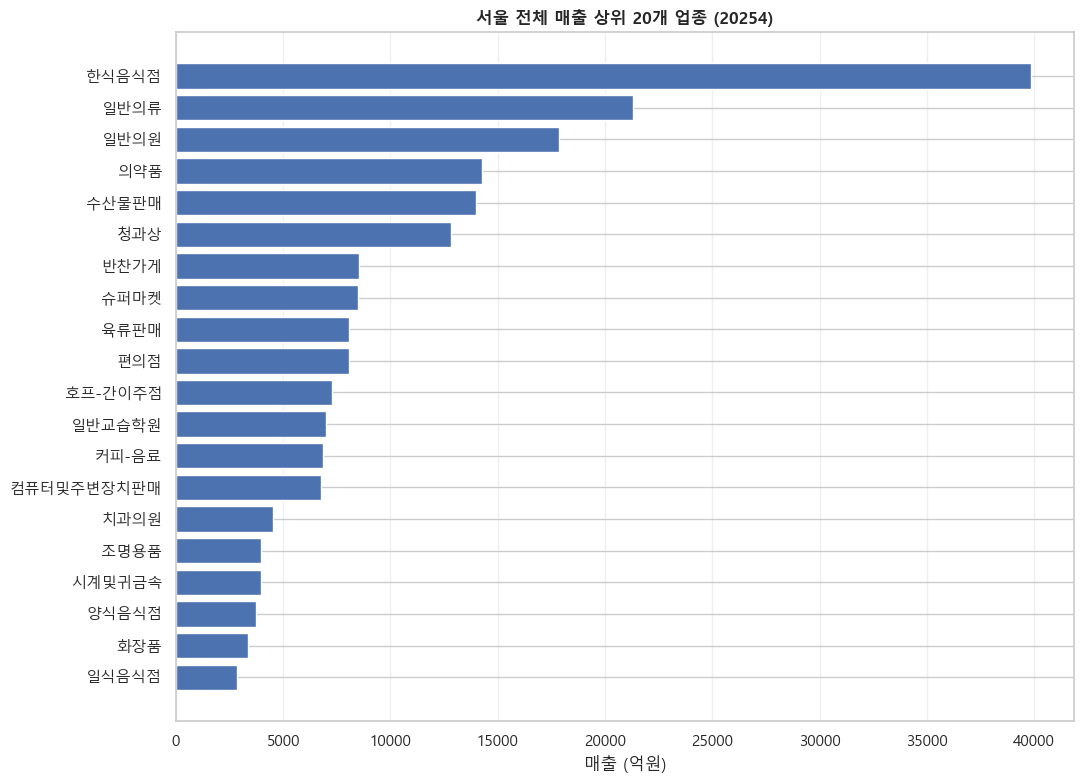

In [109]:
# TOP 20 업종 바차트
top20_업종 = 업종집계.head(20).copy()

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(top20_업종['서비스_업종_코드_명'][::-1], top20_업종['매출_억'][::-1], 
        color='#4C72B0', edgecolor='white')
ax.set_xlabel('매출 (억원)')
ax.set_title(f'서울 전체 매출 상위 20개 업종 ({LATEST_QUARTER})', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

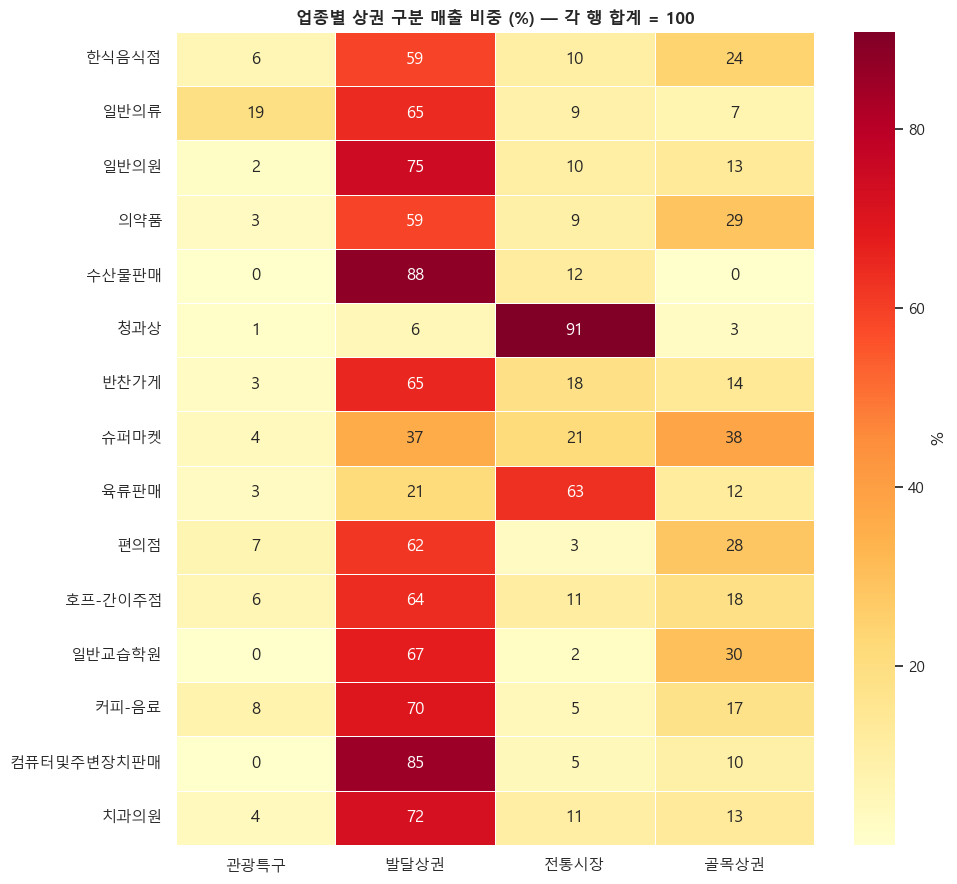

In [110]:
# 업종 × 상권구분 매출 비중 히트맵 (TOP 15 업종)
top15 = 업종집계.head(15)['서비스_업종_코드_명'].tolist()

sub = latest[latest['서비스_업종_코드_명'].isin(top15)]
pivot = sub.pivot_table(
    values='당월_매출_금액',
    index='서비스_업종_코드_명',
    columns='상권_구분_코드_명',
    aggfunc='sum'
).fillna(0)/1e8

# 컬럼 순서 정렬
pivot = pivot[[c for c in 순서 if c in pivot.columns]]

# 각 업종 행을 100%로 정규화
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct = pivot_pct.reindex(top15)

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(pivot_pct, annot=True, fmt='.0f', cmap='YlOrRd',
            cbar_kws={'label': '%'}, ax=ax, linewidths=0.5)
ax.set_title('업종별 상권 구분 매출 비중 (%) — 각 행 합계 = 100', 
             fontweight='bold', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [111]:
# 관광특구에서 특히 강한 업종 (관광객 소비 패턴 단서)
관광특구_매출 = latest[latest['상권_구분_코드_명']=='관광특구'].groupby(
    '서비스_업종_코드_명'
)['당월_매출_금액'].sum().sort_values(ascending=False)/1e8

print('🎯 관광특구 매출 TOP 15 업종 (단위: 억원)')
print(관광특구_매출.head(15).round(0))

🎯 관광특구 매출 TOP 15 업종 (단위: 억원)
서비스_업종_코드_명
일반의류      4,045.00
한식음식점     2,513.00
시계및귀금속      697.00
커피-음료       548.00
편의점         534.00
양식음식점       473.00
호프-간이주점     462.00
화장품         450.00
의약품         434.00
조명용품        379.00
슈퍼마켓        356.00
문구          354.00
운동/경기용품     339.00
중식음식점       276.00
일반의원        275.00
Name: 당월_매출_금액, dtype: float64


### Step 4 인사이트
- 매출 상위 업종은 무엇인가? (예상: 한식, 의류, 슈퍼마켓 등)
- 관광특구에 특화된 업종은? (예상: 화장품, 외국인 면세 관련)
- 골목상권 vs 관광특구의 업종 mix 차이
- 메모: 

---
## Step 5: 페르소나 분석 (성·연령·시간·요일)

목표:
- 상권 구분별로 누가/언제/어떻게 소비하는지
- 관광 상권은 평일/주말 패턴이 일상 상권과 다를 것
- 페르소나는 발달 점수 산출 후 클러스터링에도 활용 가능

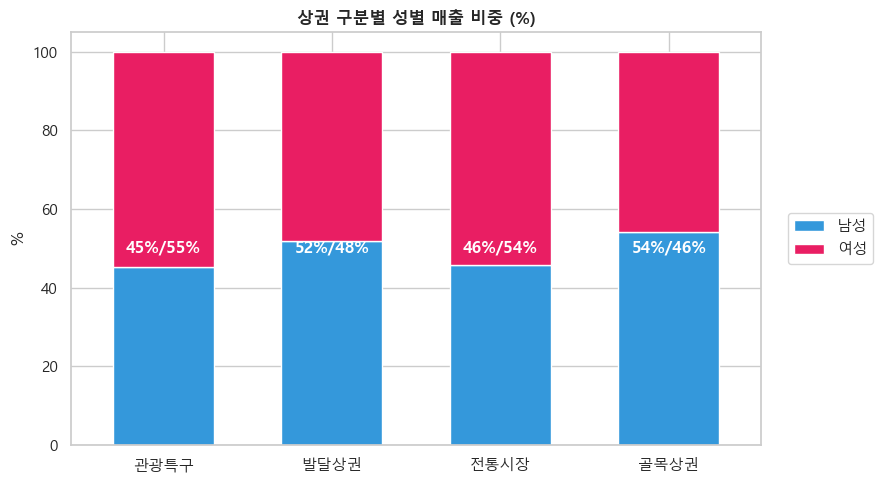

In [112]:
# 5-1. 성별 매출 비중
gender = latest.groupby('상권_구분_코드_명').agg(
    남성=('남성_매출_금액','sum'),
    여성=('여성_매출_금액','sum'),
).reindex(순서)
gender_pct = gender.div(gender.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
gender_pct.plot(kind='bar', stacked=True, ax=ax, 
                color=['#3498DB','#E91E63'], width=0.6)
ax.set_title('상권 구분별 성별 매출 비중 (%)', fontweight='bold')
ax.set_ylabel('%')
ax.set_xlabel('')
ax.legend(loc='center', bbox_to_anchor=(1.1, 0.5))
plt.xticks(rotation=0)
for i, (idx, row) in enumerate(gender_pct.iterrows()):
    ax.text(i, 50, f'{row["남성"]:.0f}%/{row["여성"]:.0f}%',
            ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout()
plt.show()

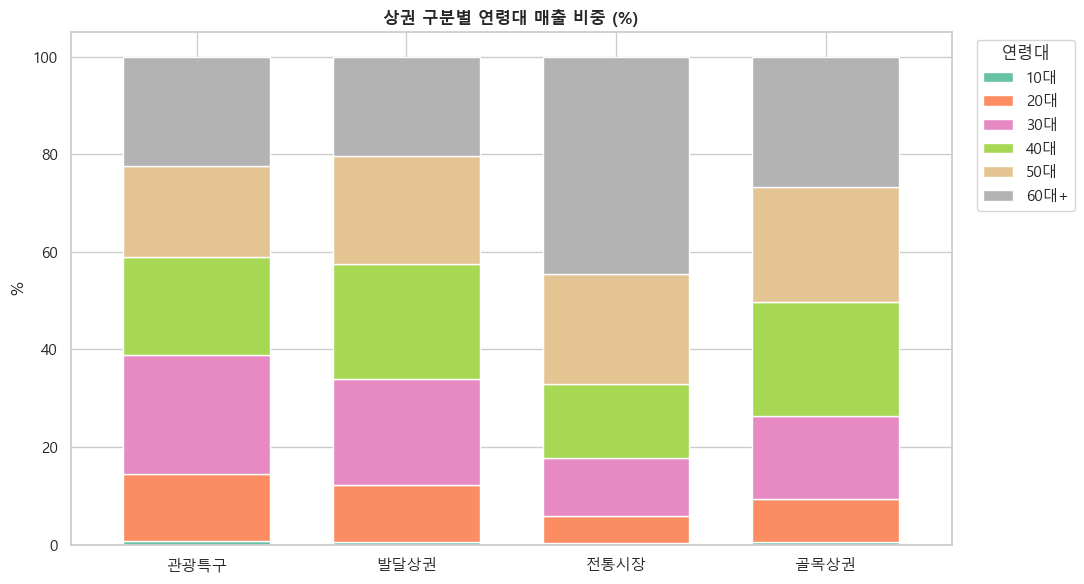


수치 (%)
            10대   20대   30대   40대   50대  60대+
상권_구분_코드_명                                   
관광특구       0.80 13.70 24.40 20.10 18.60 22.40
발달상권       0.50 11.70 21.60 23.70 22.10 20.30
전통시장       0.30  5.60 11.90 15.10 22.60 44.50
골목상권       0.50  9.00 17.00 23.30 23.50 26.70


In [113]:
# 5-2. 연령대별 매출 비중
연령컬럼 = ['연령대_10_매출_금액','연령대_20_매출_금액','연령대_30_매출_금액',
        '연령대_40_매출_금액','연령대_50_매출_금액','연령대_60_이상_매출_금액']
연령라벨 = ['10대','20대','30대','40대','50대','60대+']

age_data = latest.groupby('상권_구분_코드_명')[연령컬럼].sum().reindex(순서)
age_data.columns = 연령라벨
age_pct = age_data.div(age_data.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 6))
age_pct.plot(kind='bar', stacked=True, ax=ax, 
             colormap='Set2', width=0.7, edgecolor='white')
ax.set_title('상권 구분별 연령대 매출 비중 (%)', fontweight='bold')
ax.set_ylabel('%')
ax.set_xlabel('')
ax.legend(title='연령대', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('\n수치 (%)')
print(age_pct.round(1))

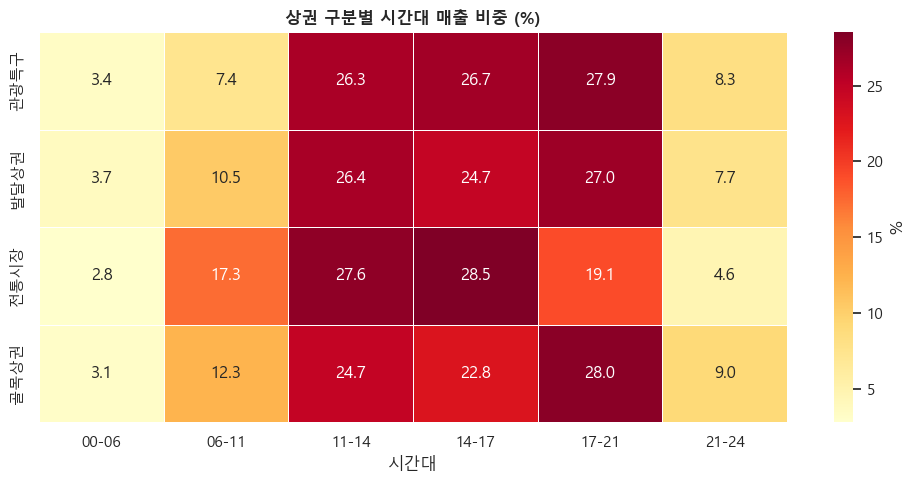

In [114]:
# 5-3. 시간대별 매출 비중 (히트맵)
시간컬럼 = ['시간대_00~06_매출_금액','시간대_06~11_매출_금액','시간대_11~14_매출_금액',
        '시간대_14~17_매출_금액','시간대_17~21_매출_금액','시간대_21~24_매출_금액']
시간라벨 = ['00-06','06-11','11-14','14-17','17-21','21-24']

time_data = latest.groupby('상권_구분_코드_명')[시간컬럼].sum().reindex(순서)
time_data.columns = 시간라벨
time_pct = time_data.div(time_data.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(time_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': '%'}, ax=ax, linewidths=0.5)
ax.set_title('상권 구분별 시간대 매출 비중 (%)', fontweight='bold')
ax.set_xlabel('시간대')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

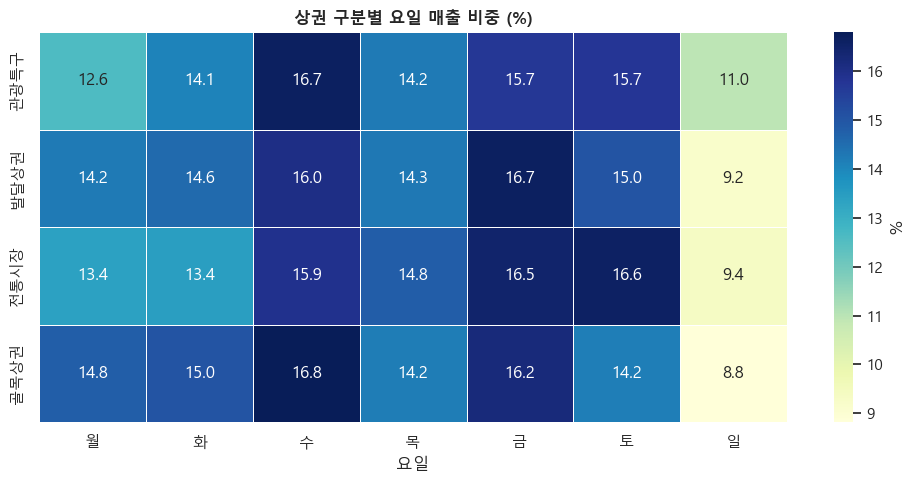


 주말(토+일) 매출 비중
상권_구분_코드_명
관광특구   26.70
발달상권   24.20
전통시장   26.00
골목상권   23.00
dtype: float64

→ 기준: 일상적 분포는 ~28.6% (1/7×2), 관광 상권은 더 높을 것


In [115]:
# 5-4. 요일별 매출 비중 (히트맵)
요일컬럼 = ['월요일_매출_금액','화요일_매출_금액','수요일_매출_금액','목요일_매출_금액',
        '금요일_매출_금액','토요일_매출_금액','일요일_매출_금액']
요일라벨 = ['월','화','수','목','금','토','일']

day_data = latest.groupby('상권_구분_코드_명')[요일컬럼].sum().reindex(순서)
day_data.columns = 요일라벨
day_pct = day_data.div(day_data.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(day_pct, annot=True, fmt='.1f', cmap='YlGnBu',
            cbar_kws={'label': '%'}, ax=ax, linewidths=0.5)
ax.set_title('상권 구분별 요일 매출 비중 (%)', fontweight='bold')
ax.set_xlabel('요일')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# 주말 비중 (토+일)
주말비중 = (day_pct['토'] + day_pct['일']).round(1)
print('\n 주말(토+일) 매출 비중')
print(주말비중)
print('\n→ 기준: 일상적 분포는 ~28.6% (1/7×2), 관광 상권은 더 높을 것')

### Step 5 인사이트
- 관광특구는 주말 비중이 골목상권보다 얼마나 높은가?
- 어떤 상권이 어느 연령대에 강한가?
- 시간대 패턴: 관광 vs 직장가 vs 주거지
- 메모: 

---
## Step 6: 시계열 트렌드 (2020~2025)

목표:
- 분기별 매출 추이
- 코로나 충격(2020~2021) → 회복(2022~)
- 상권 구분별 회복 속도 차이

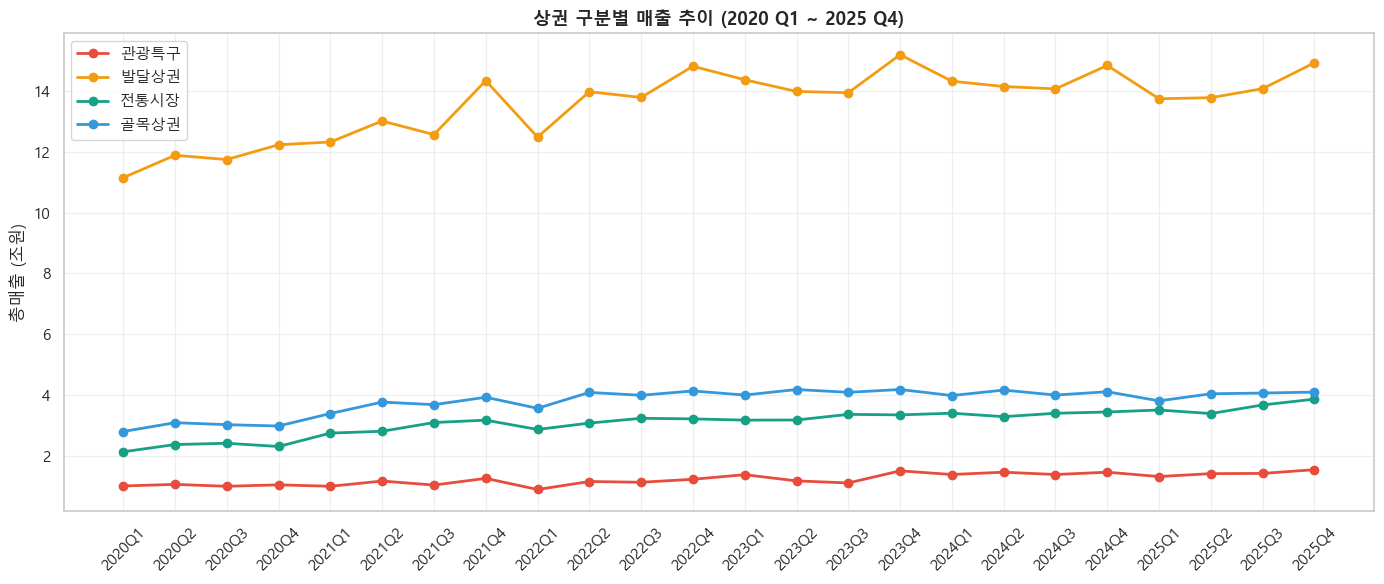

In [116]:
# 분기별 상권 구분별 총매출
trend = sales_area.groupby(['기준_년분기_코드','상권_구분_코드_명'])['당월_매출_금액'].sum().reset_index()
trend['매출_조'] = trend['당월_매출_금액']/1e12

# 라벨용 (예: 20221 → 2022Q1)
def to_label(q):
    return f'{q//10}Q{q%10}'
trend['분기라벨'] = trend['기준_년분기_코드'].apply(to_label)

fig, ax = plt.subplots(figsize=(14, 6))
for grp, color in zip(순서, colors):
    sub = trend[trend['상권_구분_코드_명']==grp].sort_values('기준_년분기_코드')
    ax.plot(sub['분기라벨'], sub['매출_조'], 
            marker='o', label=grp, linewidth=2, color=color)
ax.set_title('상권 구분별 매출 추이 (2020 Q1 ~ 2025 Q4)', fontweight='bold', fontsize=13)
ax.set_ylabel('총매출 (조원)')
ax.set_xlabel('')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [117]:
# 코로나 전후 회복률 (2020 Q1 → 2025 Q4)
period = sales_area[sales_area['기준_년분기_코드'].isin([20201, 20254])].groupby(
    ['기준_년분기_코드','상권_구분_코드_명']
)['당월_매출_금액'].sum().unstack(0)
period.columns = ['2020Q1','2025Q4']
period['성장률(%)'] = ((period['2025Q4']/period['2020Q1']-1)*100).round(1)
period['2020Q1_조'] = (period['2020Q1']/1e12).round(2)
period['2025Q4_조'] = (period['2025Q4']/1e12).round(2)
period = period.reindex(순서)
period[['2020Q1_조','2025Q4_조','성장률(%)']]

,2020Q1_조,2025Q4_조,성장률(%)
상권_구분_코드_명,,,
관광특구,1.01,1.54,53.10
발달상권,11.15,14.93,33.90
전통시장,2.13,3.86,81.30
골목상권,2.80,4.09,46.40


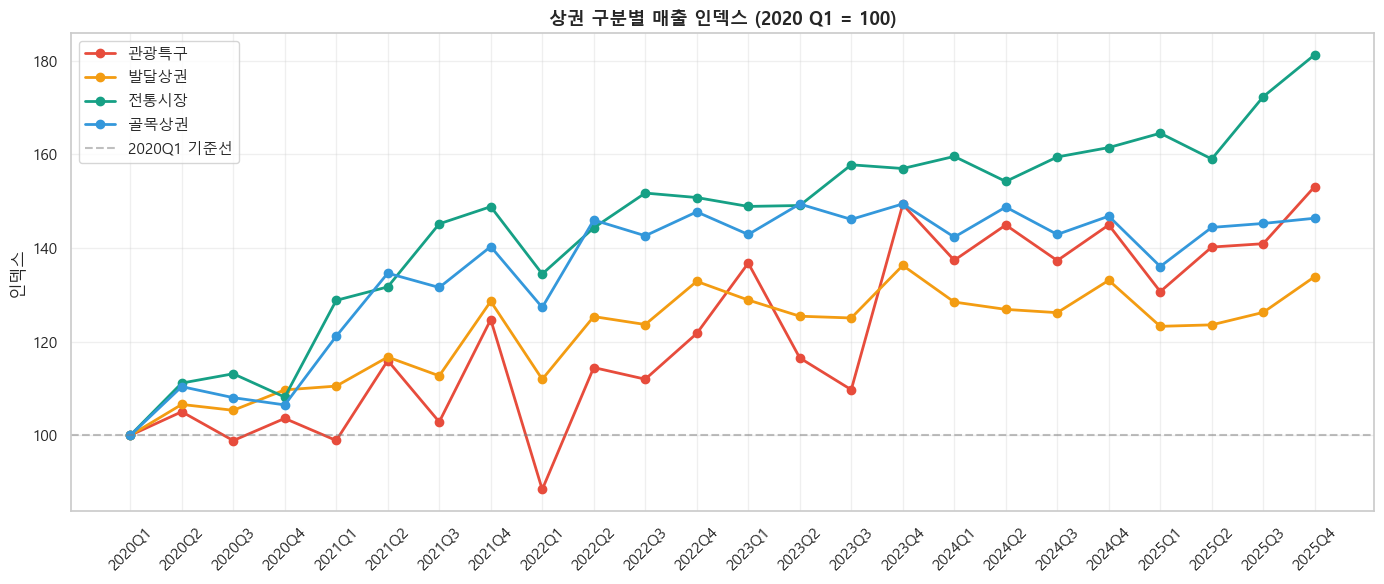

In [118]:
# 분기별 인덱스 (2020Q1 = 100) - 회복 속도 비교용
base = trend[trend['기준_년분기_코드']==20201].set_index('상권_구분_코드_명')['당월_매출_금액']
trend['인덱스'] = trend.apply(
    lambda r: r['당월_매출_금액']/base[r['상권_구분_코드_명']]*100, axis=1
)

fig, ax = plt.subplots(figsize=(14, 6))
for grp, color in zip(순서, colors):
    sub = trend[trend['상권_구분_코드_명']==grp].sort_values('기준_년분기_코드')
    ax.plot(sub['분기라벨'], sub['인덱스'], 
            marker='o', label=grp, linewidth=2, color=color)
ax.axhline(100, color='gray', linestyle='--', alpha=0.5, label='2020Q1 기준선')
ax.set_title('상권 구분별 매출 인덱스 (2020 Q1 = 100)', fontweight='bold', fontsize=13)
ax.set_ylabel('인덱스')
ax.set_xlabel('')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [119]:
# 연도별 총매출 (분기별 합산을 연 단위로)
sales_area['연도'] = sales_area['기준_년분기_코드']//10
연도별 = sales_area.groupby(['연도','상권_구분_코드_명'])['당월_매출_금액'].sum().unstack()/1e12
연도별 = 연도별[순서]
연도별.round(2)

상권_구분_코드_명,관광특구,발달상권,전통시장,골목상권
연도,,,,
2020,4.10,47.01,9.22,11.89
2021,4.46,52.25,11.82,14.76
2022,4.40,55.07,12.39,15.77
2023,5.16,57.50,13.06,16.44
2024,5.69,57.39,13.52,16.25
2025,5.69,56.53,14.43,16.00


### Step 6 인사이트
- 관광특구는 코로나 충격이 가장 컸을 것 (외국인 입국 막힘)
- 2022~2023년 회복 시작, 2024~2025년 정상화 추세 예상
- 골목상권은 상대적으로 안정적이었을 가능성 (지역 주민 수요)
- 발달상권은 직장가 중심 → 재택근무 영향 가능
- 메모: 

## 나경 EDA - 상권변화지표

In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [121]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [122]:
from pathlib import Path

current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent

csv_path = project_root / 'data' / '08_상권변화지표' / '서울시 상권분석서비스(상권변화지표-상권).csv'

df = pd.read_csv(csv_path, encoding='cp949')
print(f'✅ 로드 완료: {df.shape}')

✅ 로드 완료: (46200, 11)


In [123]:
# 기본 정보 확인
print("shape:", df.shape)
print()
print("columns:", df.columns.tolist())
print()
print("dtypes:")
print(df.dtypes)

shape: (46200, 11)

columns: ['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '상권_변화_지표', '상권_변화_지표_명', '운영_영업_개월_평균', '폐업_영업_개월_평균', '서울_운영_영업_개월_평균', '서울_폐업_영업_개월_평균']

dtypes:
기준_년분기_코드          int64
상권_구분_코드          object
상권_구분_코드_명        object
상권_코드              int64
상권_코드_명           object
상권_변화_지표          object
상권_변화_지표_명        object
운영_영업_개월_평균        int64
폐업_영업_개월_평균        int64
서울_운영_영업_개월_평균     int64
서울_폐업_영업_개월_평균     int64
dtype: object


In [124]:
# 결측치 확인
print("결측치:")
print(df.isnull().sum())
print()

# 기본 통계
df.describe()

결측치:
기준_년분기_코드         0
상권_구분_코드          0
상권_구분_코드_명        0
상권_코드             0
상권_코드_명           0
상권_변화_지표          0
상권_변화_지표_명        0
운영_영업_개월_평균       0
폐업_영업_개월_평균       0
서울_운영_영업_개월_평균    0
서울_폐업_영업_개월_평균    0
dtype: int64



,기준_년분기_코드,상권_코드,운영_영업_개월_평균,폐업_영업_개월_평균,서울_운영_영업_개월_평균,서울_폐업_영업_개월_평균
count,"46,200.00","46,200.00","46,200.00","46,200.00","46,200.00","46,200.00"
mean,"20,222.50","3,115,221.90",105.05,51.44,99.71,50.36
std,20.03,"10,318.64",25.40,10.18,7.03,1.59
min,"20,191.00","3,001,491.00",0.00,17.00,92.00,48.00
25%,"20,203.75","3,110,407.00",90.00,46.00,93.00,49.00
50%,"20,222.50","3,110,819.50",101.00,50.00,98.50,50.00
75%,"20,241.25","3,120,142.00",116.00,55.00,103.50,52.00
max,"20,254.00","3,130,327.00",351.00,226.00,115.00,53.00


## 기본정보
- 행: 46,200개 / 컬럼: 11개
- 결측치: 없음 

## 주요 통계
- 운영_영업_개월_평균: 평균 105개월 (약 8.7년), 최대 351개월 (약 29년)
- 폐업_영업_개월_평균: 평균 51개월 (약 4.3년)
- 서울_운영_영업_개월_평균: 평균 99개월 (서울 전체 기준)
- 서울_폐업_영업_개월_평균: 평균 50개월 (서울 전체 기준)

##  이상치 의심
- 운영_영업_개월_평균 최솟값 0개월 → 추후 확인 필요

In [125]:
# 연도/분기 고유값 확인
print("기준_년분기_코드 고유값:")
print(sorted(df['기준_년분기_코드'].unique()))
print()

# 상권 유형 고유값 확인
print("상권_구분_코드_명 고유값:")
print(df['상권_구분_코드_명'].unique())
print()

# 상권 변화 지표 고유값 확인
print("상권_변화_지표_명 고유값:")
print(df['상권_변화_지표_명'].unique())

기준_년분기_코드 고유값:
[np.int64(20191), np.int64(20192), np.int64(20193), np.int64(20194), np.int64(20201), np.int64(20202), np.int64(20203), np.int64(20204), np.int64(20211), np.int64(20212), np.int64(20213), np.int64(20214), np.int64(20221), np.int64(20222), np.int64(20223), np.int64(20224), np.int64(20231), np.int64(20232), np.int64(20233), np.int64(20234), np.int64(20241), np.int64(20242), np.int64(20243), np.int64(20244), np.int64(20251), np.int64(20252), np.int64(20253), np.int64(20254)]

상권_구분_코드_명 고유값:
['관광특구' '전통시장' '발달상권' '골목상권']

상권_변화_지표_명 고유값:
['정체' '다이나믹' '상권확장' '상권축소']


## 카테고리 값 확인
- 기간: 2019 Q1 ~ 2025 Q4 (28개 분기) ✅
- 상권 유형: 관광특구 / 전통시장 / 발달상권 / 골목상권
- 변화 지표: 상권확장 / 상권축소 / 다이나믹 / 정체

In [126]:
# 팀원 데이터 JOIN 키 형식 확인
print("상권_코드 샘플:", df['상권_코드'].head().tolist())
print("상권_코드 타입:", df['상권_코드'].dtype)
print()
print("기준_년분기_코드 샘플:", df['기준_년분기_코드'].head().tolist())
print("기준_년분기_코드 타입:", df['기준_년분기_코드'].dtype)

상권_코드 샘플: [3001496, 3001495, 3001494, 3001493, 3001492]
상권_코드 타입: int64

기준_년분기_코드 샘플: [20254, 20254, 20254, 20254, 20254]
기준_년분기_코드 타입: int64


## JOIN 키 확인
- 상권_코드: int형, 예) 1000001 형태
- 기준_년분기_코드: int형, 예) 20191 형태
- 키 형식 동일한지 합칠 때 재확인 필요

In [127]:
# 분석 기간 필터링 (2019~2024만 사용)
df = df[df['기준_년분기_코드'] < 20250]

In [128]:
# 상위 5개 데이터 확인
df.head()

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,상권_변화_지표,상권_변화_지표_명,운영_영업_개월_평균,폐업_영업_개월_평균,서울_운영_영업_개월_평균,서울_폐업_영업_개월_평균
6600,20244,U,관광특구,3001496,강남 마이스 관광특구,HH,정체,116,66,109,52
6601,20244,U,관광특구,3001495,잠실 관광특구,LL,다이나믹,94,51,109,52
6602,20244,U,관광특구,3001494,종로?청계 관광특구,HH,정체,163,73,109,52
6603,20244,U,관광특구,3001493,동대문패션타운 관광특구,HH,정체,116,62,109,52
6604,20244,U,관광특구,3001492,명동 남대문 북창동 다동 무교동 관광특구,HH,정체,141,65,109,52


In [129]:
# 상권_변화_지표 고유값 확인
print(df['상권_변화_지표'].unique())

['HH' 'LL' 'LH' 'HL']


## 상권_변화_지표 코드 의미
- HH (정체): 운영↑ 폐업↑ - 변화 적은 상권
- LL (다이나믹): 운영↓ 폐업↓ - 빠른 회전 상권
- HL (상권확장): 운영↑ 폐업↓ - 성장 중인 상권
- LH (상권축소): 운영↓ 폐업↑ - 취약상권 후보 

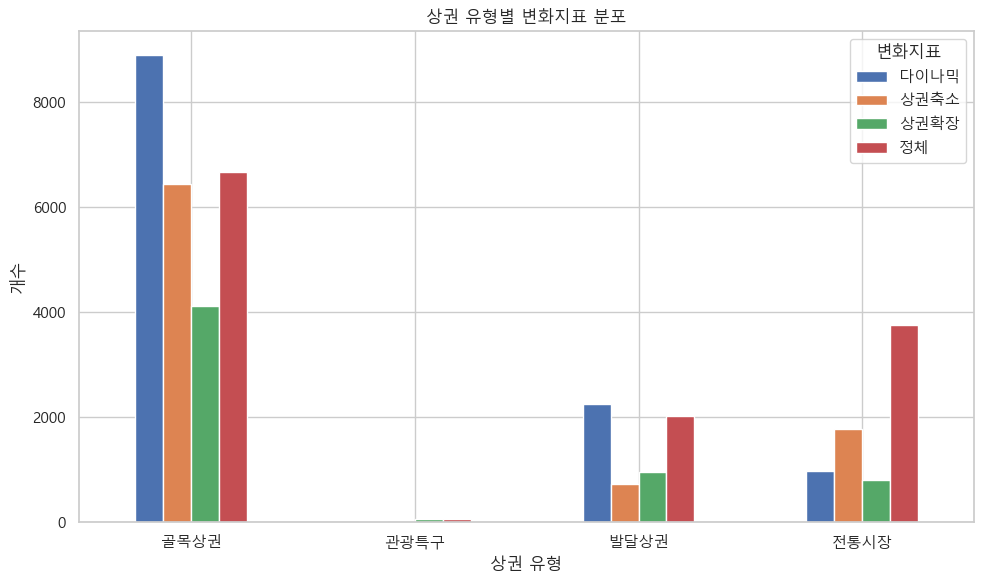

In [130]:
# 상권 유형별 변화지표 분포 시각화
fig, ax = plt.subplots(figsize=(10, 6))

# 상권 유형별 변화지표 개수 계산
pivot = df.groupby(['상권_구분_코드_명', '상권_변화_지표_명']).size().unstack()

# 막대 그래프
pivot.plot(kind='bar', ax=ax)


ax.set_title('상권 유형별 변화지표 분포')
ax.set_xlabel('상권 유형')
ax.set_ylabel('개수')
ax.legend(title='변화지표')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 상권 유형별 변화지표 분포
- 골목상권: 다이나믹 비율 가장 높음 → 빠른 개폐업 반복, 불안정
- 관광특구: 데이터 수 적음 → 상권 수 자체가 적음
- 발달상권: 다이나믹 + 정체 혼재
- 전통시장: 정체 비율 압도적 → 변화 없는 고착형 상권

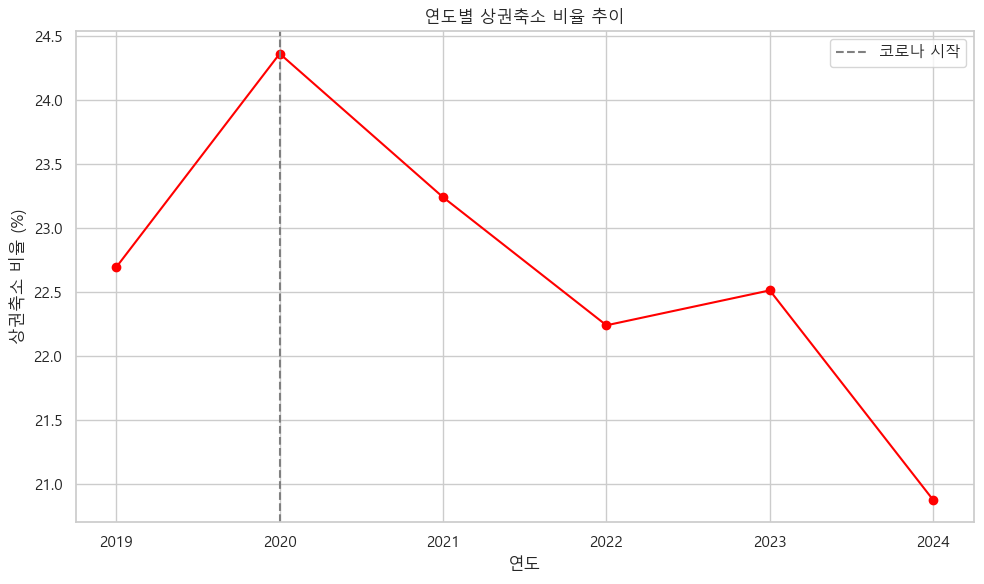

In [131]:
# 연도별 상권축소 비율 추이
# 분기코드에서 연도만 추출
df['연도'] = df['기준_년분기_코드'].astype(str).str[:4].astype(int)

# 연도별 상권축소 비율 계산
total = df.groupby('연도').size()
축소 = df[df['상권_변화_지표_명'] == '상권축소'].groupby('연도').size()
축소_비율 = (축소 / total * 100).reset_index()
축소_비율.columns = ['연도', '상권축소_비율']

# 그래프
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(축소_비율['연도'], 축소_비율['상권축소_비율'], marker='o', color='red')

# 코로나 시점 표시
ax.axvline(x=2020, color='gray', linestyle='--', label='코로나 시작')

ax.set_title('연도별 상권축소 비율 추이')
ax.set_xlabel('연도')
ax.set_ylabel('상권축소 비율 (%)')
ax.legend()
plt.tight_layout()
plt.show()

## 연도별 상권축소 비율 추이
- 2020년 코로나 타격으로 상권축소 비율 최고점(24.4%)
- 2022년부터 회복세
- 2024~2025년 역대 최저(21%) → 코로나 이전보다 오히려 개선

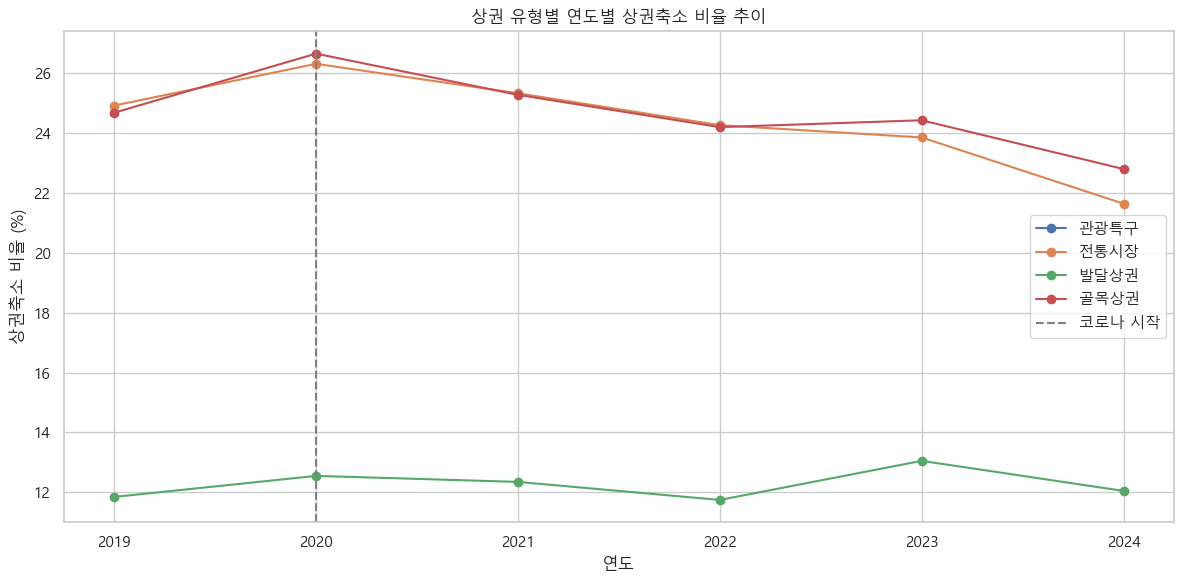

In [132]:
# 상권 유형별 연도별 축소 비율 추이
fig, ax = plt.subplots(figsize=(12, 6))

# 유형별로 연도별 축소 비율 계산
for 유형 in df['상권_구분_코드_명'].unique():
    df_유형 = df[df['상권_구분_코드_명'] == 유형]
    total = df_유형.groupby('연도').size()
    축소 = df_유형[df_유형['상권_변화_지표_명'] == '상권축소'].groupby('연도').size()
    비율 = (축소 / total * 100)
    ax.plot(비율.index, 비율.values, marker='o', label=유형)

# 코로나 시점 표시
ax.axvline(x=2020, color='gray', linestyle='--', label='코로나 시작')

ax.set_title('상권 유형별 연도별 상권축소 비율 추이')
ax.set_xlabel('연도')
ax.set_ylabel('상권축소 비율 (%)')
ax.legend()
plt.tight_layout()
plt.show()

## 상권 유형별 연도별 상권축소 비율 추이
- 전 유형 2020년 코로나로 최고점
- 발달상권: 타격 가장 적음 (12%대 유지)
- 전통시장: 회복 속도 가장 빠름
- 골목상권: 여전히 높은 축소 비율 → 가장 취약 

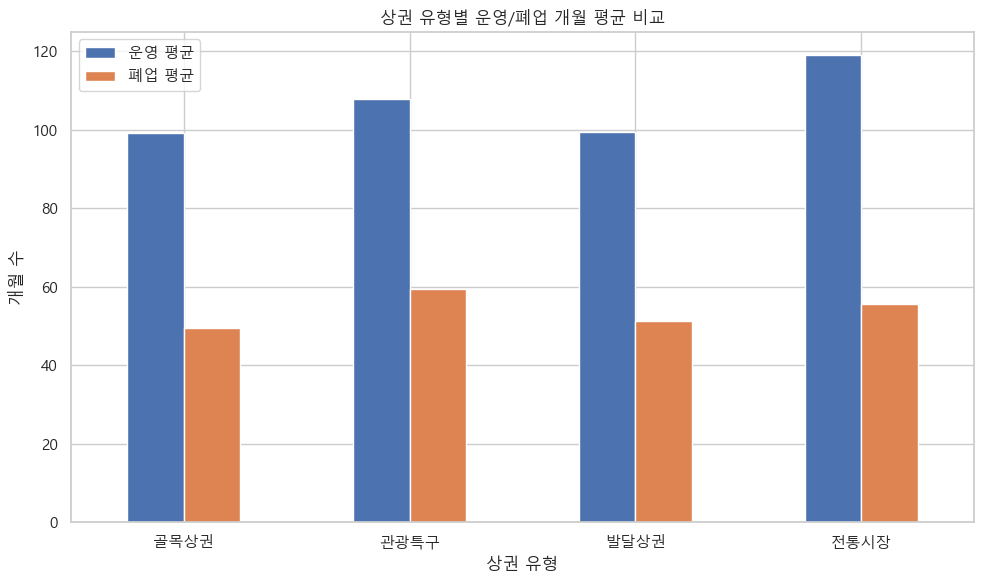

In [133]:
# 상권 유형별 운영/폐업 개월 평균 비교
fig, ax = plt.subplots(figsize=(10, 6))

# 유형별 평균 계산
평균 = df.groupby('상권_구분_코드_명')[['운영_영업_개월_평균', '폐업_영업_개월_평균']].mean()

# 막대 그래프
평균.plot(kind='bar', ax=ax)

ax.set_title('상권 유형별 운영/폐업 개월 평균 비교')
ax.set_xlabel('상권 유형')
ax.set_ylabel('개월 수')
ax.legend(['운영 평균', '폐업 평균'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 상권 유형별 운영/폐업 개월 평균 비교
- 전통시장: 운영 평균 121개월(약 10년)로 가장 길음 → 고착형 상권
- 관광특구: 폐업까지 가장 오래 버팀 (60개월)
- 골목/발달상권: 운영 평균 유사 (약 101개월)

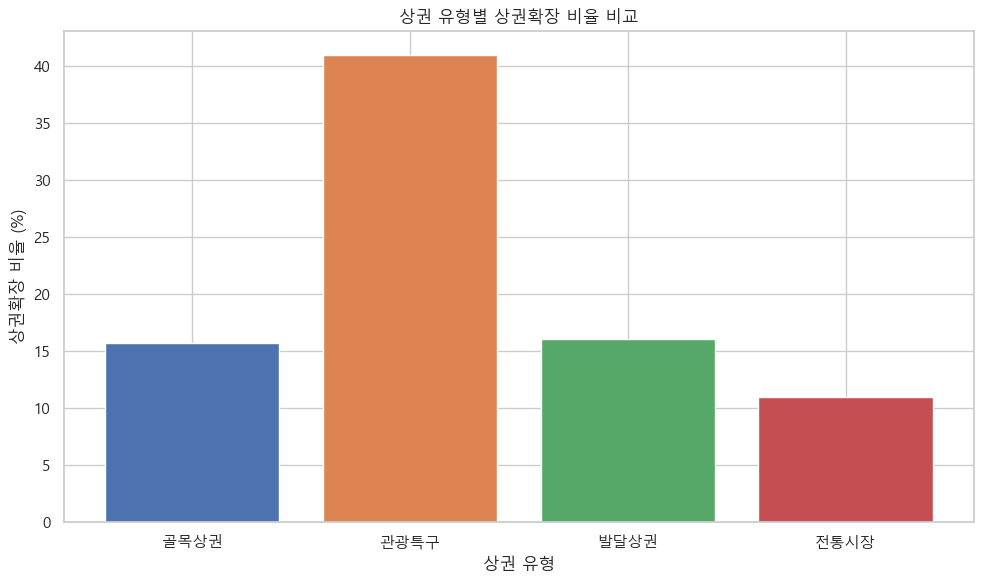

In [134]:
# 상권 유형별 상권확장 비율 비교
fig, ax = plt.subplots(figsize=(10, 6))

# 유형별 상권확장 비율 계산
total = df.groupby('상권_구분_코드_명').size()
확장 = df[df['상권_변화_지표_명'] == '상권확장'].groupby('상권_구분_코드_명').size()
확장_비율 = (확장 / total * 100).reset_index()
확장_비율.columns = ['상권_구분_코드_명', '상권확장_비율']

# 막대 그래프
ax.bar(확장_비율['상권_구분_코드_명'], 확장_비율['상권확장_비율'], color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])

ax.set_title('상권 유형별 상권확장 비율 비교')
ax.set_xlabel('상권 유형')
ax.set_ylabel('상권확장 비율 (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 상권 유형별 상권확장 비율 비교
- 관광특구: 37%로 압도적 1위 → 성장 잠재력 가장 강함
- 골목/발달상권: 16%로 유사
- 전통시장: 11%로 가장 낮음 → 고착형, 정책 지원 필요 

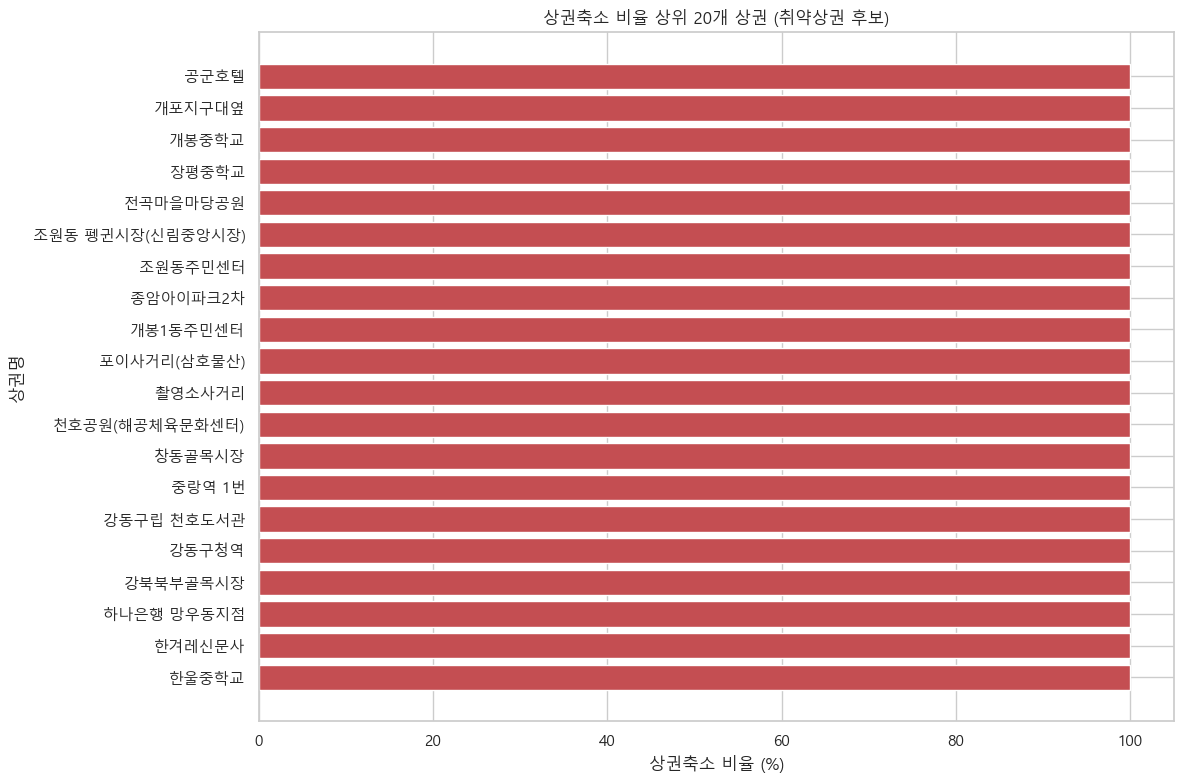

In [135]:
# 취약상권 후보 추출 (상권축소 비율 상위 상권 목록)
fig, ax = plt.subplots(figsize=(12, 8))

# 상권별 전체 분기 중 상권축소 비율 계산
total = df.groupby('상권_코드_명').size()
축소 = df[df['상권_변화_지표_명'] == '상권축소'].groupby('상권_코드_명').size()
축소_비율 = (축소 / total * 100).dropna().sort_values(ascending=False).head(20)

# 가로 막대 그래프
ax.barh(축소_비율.index, 축소_비율.values, color='#C44E52')

ax.set_title('상권축소 비율 상위 20개 상권 (취약상권 후보)')
ax.set_xlabel('상권축소 비율 (%)')
ax.set_ylabel('상권명')
plt.tight_layout()
plt.show()

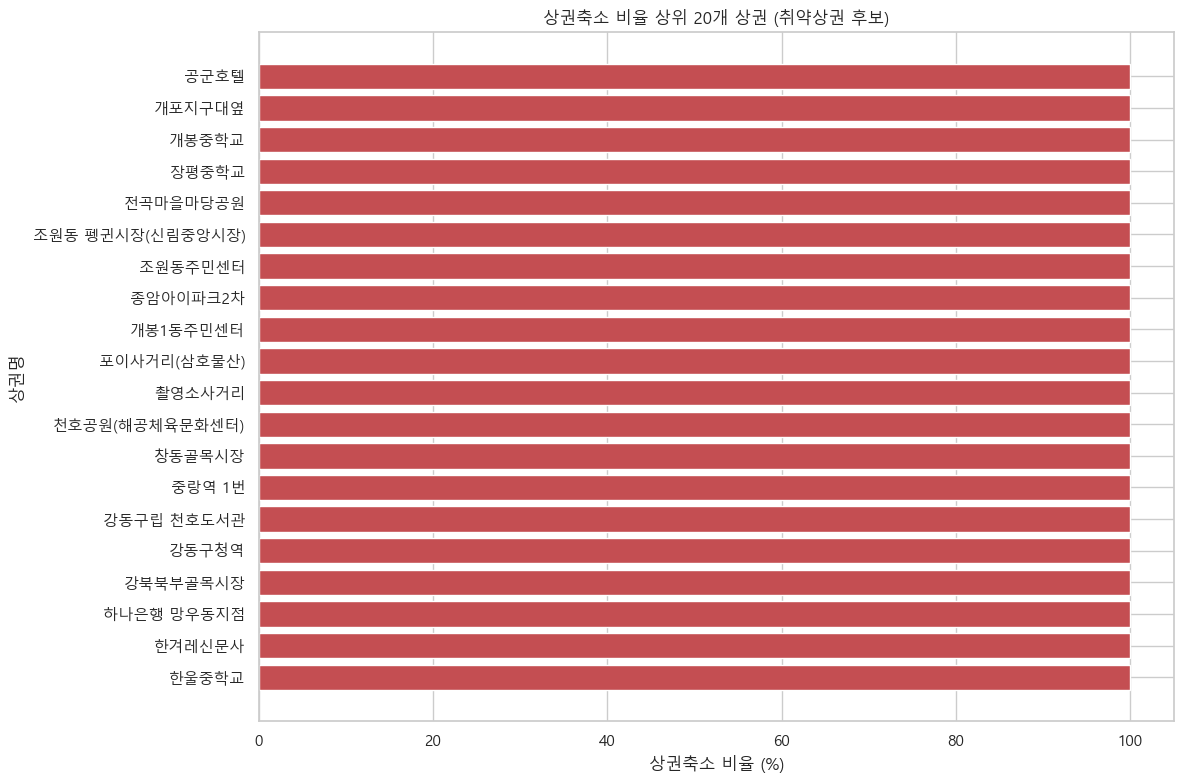

In [136]:
# 최소 8분기 이상 등장한 상권만 필터링 (2년치 이상)
fig, ax = plt.subplots(figsize=(12, 8))

total = df.groupby('상권_코드_명').size()
축소 = df[df['상권_변화_지표_명'] == '상권축소'].groupby('상권_코드_명').size()
축소_비율 = (축소 / total * 100).dropna()

# 최소 8분기 이상인 상권만
유효상권 = total[total >= 8].index
축소_비율 = 축소_비율[축소_비율.index.isin(유효상권)]
축소_비율 = 축소_비율.sort_values(ascending=False).head(20)

ax.barh(축소_비율.index, 축소_비율.values, color='#C44E52')
ax.set_title('상권축소 비율 상위 20개 상권 (취약상권 후보)')
ax.set_xlabel('상권축소 비율 (%)')
ax.set_ylabel('상권명')
plt.tight_layout()
plt.show()

In [137]:
# 몇 분기씩 등장하는지 확인
print(total.describe())
print()
print("20분기 이상 상권 수:", len(total[total >= 20]))

count   1,650.00
mean       24.00
std         0.00
min        24.00
25%        24.00
50%        24.00
75%        24.00
max        24.00
dtype: float64

20분기 이상 상권 수: 1650


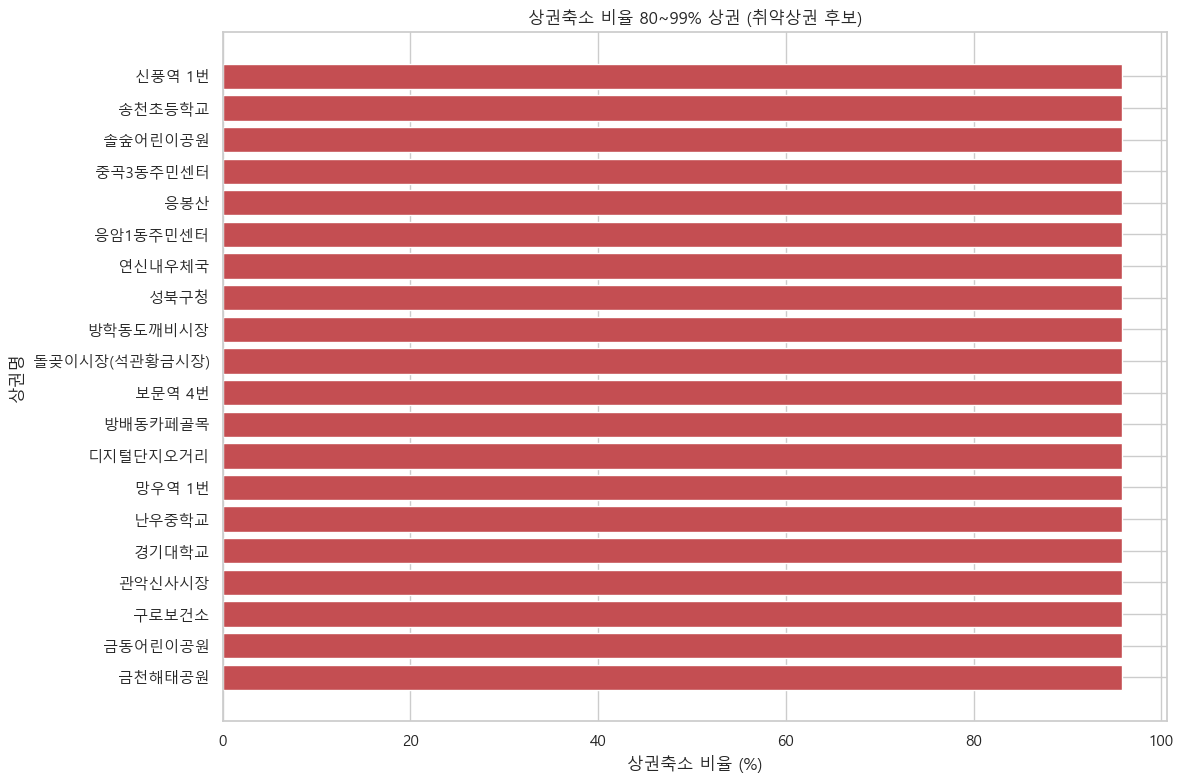

In [138]:
# 상권 유형 정보 추가해서 취약상권 후보 추출
fig, ax = plt.subplots(figsize=(12, 8))

total = df.groupby('상권_코드_명').size()
축소 = df[df['상권_변화_지표_명'] == '상권축소'].groupby('상권_코드_명').size()
축소_비율 = (축소 / total * 100).dropna()

# 80% 이상 축소된 상권만 (100% 제외)
축소_비율 = 축소_비율[(축소_비율 >= 80) & (축소_비율 < 100)]
축소_비율 = 축소_비율.sort_values(ascending=False).head(20)

ax.barh(축소_비율.index, 축소_비율.values, color='#C44E52')
ax.set_title('상권축소 비율 80~99% 상권 (취약상권 후보)')
ax.set_xlabel('상권축소 비율 (%)')
ax.set_ylabel('상권명')
plt.tight_layout()
plt.show()

In [139]:
# 축소 비율 분포 확인
print(축소_비율.value_counts().head(10))
print()
print("100% 상권 수:", len(축소_비율[축소_비율 == 100]))
print("80~99% 상권 수:", len(축소_비율[(축소_비율 >= 80) & (축소_비율 < 100)]))
print("50~79% 상권 수:", len(축소_비율[(축소_비율 >= 50) & (축소_비율 < 80)]))

95.83    20
Name: count, dtype: int64

100% 상권 수: 0
80~99% 상권 수: 20
50~79% 상권 수: 0


In [140]:
# 취약상권 후보 20개 상권 유형 확인
취약상권 = 축소_비율[축소_비율 >= 80].index.tolist()

# 유형 정보 붙이기
취약_df = df[df['상권_코드_명'].isin(취약상권)][['상권_코드_명', '상권_구분_코드_명']].drop_duplicates()
print(취약_df['상권_구분_코드_명'].value_counts())
print()
print(취약_df)

상권_구분_코드_명
골목상권    14
전통시장     3
발달상권     3
Name: count, dtype: int64

            상권_코드_명 상권_구분_코드_명
6650         관악신사시장       전통시장
6779       방학동도깨비시장       전통시장
6799  돌곶이시장(석관황금시장)       전통시장
6998        방배동카페골목       발달상권
7034       디지털단지오거리       발달상권
7089           성북구청       발달상권
7384          난우중학교       골목상권
7446         신풍역 1번       골목상권
7510         금천해태공원       골목상권
7537          구로보건소       골목상권
7716          경기대학교       골목상권
7765         연신내우체국       골목상권
7772       응암1동주민센터       골목상권
7882         송천초등학교       골목상권
7946         보문역 4번       골목상권
7952        솔숲어린이공원       골목상권
7985         망우역 1번       골목상권
8092       중곡3동주민센터       골목상권
8137            응봉산       골목상권
8145        금동어린이공원       골목상권


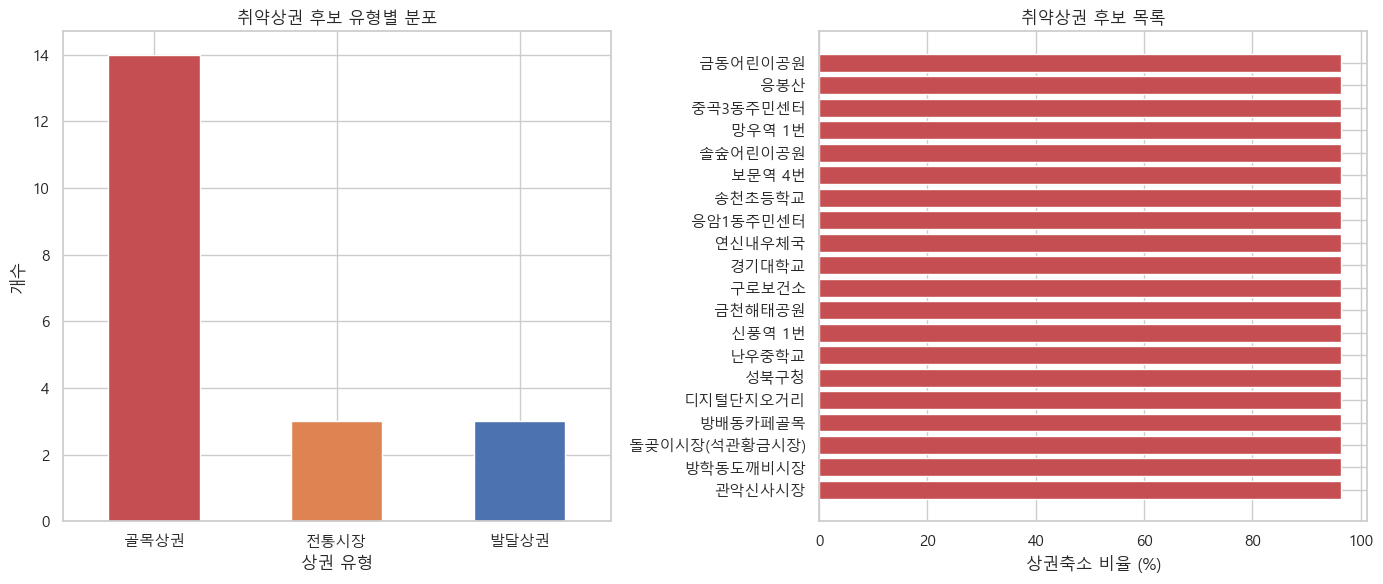

In [141]:
# 취약상권 후보 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 왼쪽: 유형별 개수
취약_df['상권_구분_코드_명'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#C44E52', '#DD8452', '#4C72B0']
)
axes[0].set_title('취약상권 후보 유형별 분포')
axes[0].set_xlabel('상권 유형')
axes[0].set_ylabel('개수')
axes[0].tick_params(axis='x', rotation=0)

# 오른쪽: 상권명 목록
axes[1].barh(취약_df['상권_코드_명'], [96.4]*len(취약_df), color='#C44E52')
axes[1].set_title('취약상권 후보 목록')
axes[1].set_xlabel('상권축소 비율 (%)')

plt.tight_layout()
plt.show()

## 취약상권 후보 도출 과정
- 상권별 전체 분기 중 상권축소 비율 계산
- 처음 100% 상권 등장 → 데이터 적은 상권이 잡힌 것 → 80~99% 구간으로 필터링
- 결과: 28분기 중 27분기가 상권축소인 상권 20개 (96.4%) 추출

## 취약상권 후보 해석
- 골목상권 11개(55%): 구조적으로 가장 취약한 유형
- 전통시장 5개(25%): 양재시장, 창동골목시장 등 오래된 시장 만성 축소 중
- 발달상권 4개(20%): 유동인구 감소 또는 상권 이동 가능성

## 최종 인사이트
- 서울 상권은 전반적으로 코로나 회복 완료
- 단, 골목상권·일부 전통시장은 코로나와 무관하게 만성적 축소 중

## 나경 EDA - 직장인구/상주인구

In [142]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [143]:
from pathlib import Path
import zipfile
import shutil

# 프로젝트 루트 감지
current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent

# 경로 설정
target_dir = project_root / 'data' / '06_직장인구'
csv_path = target_dir / '서울시 상권분석서비스(직장인구-상권).csv'

# CSV 없으면 raw/ 에서 zip 찾아서 압축 해제
if not csv_path.exists():
    print('📦 CSV 없음, zip 파일 찾는 중...')
    raw_dir = project_root / 'data' / 'raw'
    
    # 직장인구 관련 zip 찾기
    zip_files = list(raw_dir.glob('*직장인구*.zip'))
    if not zip_files:
        raise FileNotFoundError(f'{raw_dir} 에 직장인구 zip 없음')
    
    zip_path = zip_files[0]
    print(f'  압축 해제: {zip_path.name}')
    target_dir.mkdir(parents=True, exist_ok=True)
    
    # Mac zip의 한글 파일명 문제 해결
    with zipfile.ZipFile(zip_path, 'r') as z:
        for info in z.infolist():
            if info.filename.startswith('__MACOSX'):
                continue
            try:
                filename = info.filename.encode('cp437').decode('utf-8')
            except:
                filename = info.filename
            
            if info.is_dir():
                continue
            
            out_path = target_dir / filename
            out_path.parent.mkdir(parents=True, exist_ok=True)
            with z.open(info) as src, open(out_path, 'wb') as dst:
                shutil.copyfileobj(src, dst)

# CSV 로드
df_직장 = pd.read_csv(csv_path, encoding='cp949')
print(f'✅ 직장인구 로드 완료: {df_직장.shape}')

📦 CSV 없음, zip 파일 찾는 중...
  압축 해제: 서울시 상권분석서비스(직장인구-상권).zip
✅ 직장인구 로드 완료: (45840, 26)


In [144]:
from pathlib import Path

current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent

# 06_직장인구 폴더로 수정 ✅
csv_path = project_root / 'data' / '06_직장인구' / '서울시 상권분석서비스(직장인구-상권).csv'

df = pd.read_csv(csv_path, encoding='cp949')
print(f'✅ 로드 완료: {df.shape}')

✅ 로드 완료: (45840, 26)


In [145]:
# 분석 기간 필터링 (2019~2024)
df_직장 = df_직장[df_직장['기준_년분기_코드'] < 20250]

print("shape:", df_직장.shape)
print("기간:", sorted(df_직장['기준_년분기_코드'].unique()))
print("상권 유형:", df_직장['상권_구분_코드_명'].unique())
df_직장.head()

shape: (39276, 26)
기간: [np.int64(20191), np.int64(20192), np.int64(20193), np.int64(20194), np.int64(20201), np.int64(20202), np.int64(20203), np.int64(20204), np.int64(20211), np.int64(20212), np.int64(20213), np.int64(20214), np.int64(20221), np.int64(20222), np.int64(20223), np.int64(20224), np.int64(20231), np.int64(20232), np.int64(20233), np.int64(20234), np.int64(20241), np.int64(20242), np.int64(20243), np.int64(20244)]
상권 유형: ['관광특구' '전통시장' '발달상권' '골목상권']


,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,총_직장_인구_수,남성_직장_인구_수,여성_직장_인구_수,연령대_10_직장_인구_수,연령대_20_직장_인구_수,연령대_30_직장_인구_수,연령대_40_직장_인구_수,연령대_50_직장_인구_수,연령대_60_이상_직장_인구_수,남성연령대_10_직장_인구_수,남성연령대_20_직장_인구_수,남성연령대_30_직장_인구_수,남성연령대_40_직장_인구_수,남성연령대_50_직장_인구_수,남성연령대_60_이상_직장_인구_수,여성연령대_10_직장_인구_수,여성연령대_20_직장_인구_수,여성연령대_30_직장_인구_수,여성연령대_40_직장_인구_수,여성연령대_50_직장_인구_수,여성연령대_60_이상_직장_인구_수
6564,20244,U,관광특구,3001496,강남 마이스 관광특구,102032,68834,33198,260,20558,30594,27320,18116,5184,128,11046,20220,20142,14200,3098,132,9512,10374,7178,3916,2086
6565,20244,U,관광특구,3001495,잠실 관광특구,137602,81307,56295,247,22732,36053,35461,30321,12788,95,11243,22723,22594,16132,8520,152,11489,13330,12867,14189,4268
6566,20244,U,관광특구,3001494,종로?청계 관광특구,46516,26098,20418,658,9450,13848,12650,7438,2472,234,4072,7232,7590,5236,1734,424,5378,6616,5060,2202,738
6567,20244,U,관광특구,3001493,동대문패션타운 관광특구,33754,16984,16770,259,9770,8679,6878,5414,2754,101,4677,5003,3924,2083,1196,158,5093,3676,2954,3331,1558
6568,20244,U,관광특구,3001492,명동 남대문 북창동 다동 무교동 관광특구,199667,114485,85182,372,40531,66760,51480,31752,8772,83,15500,35220,34082,23643,5957,289,25031,31540,17398,8109,2815


In [146]:
# 결측치 확인
print("결측치:")
print(df_직장.isnull().sum())
print()

# 분석 기간 확인 (2019Q1~2024Q4 맞는지)
print("기간:", sorted(df_직장['기준_년분기_코드'].unique()))
print()

# 상권 유형 확인 (4개 다 있는지)
print("상권 유형:", df_직장['상권_구분_코드_명'].unique())

결측치:
기준_년분기_코드              0
상권_구분_코드               0
상권_구분_코드_명             0
상권_코드                  0
상권_코드_명                0
총_직장_인구_수              0
남성_직장_인구_수             0
여성_직장_인구_수             0
연령대_10_직장_인구_수         0
연령대_20_직장_인구_수         0
연령대_30_직장_인구_수         0
연령대_40_직장_인구_수         0
연령대_50_직장_인구_수         0
연령대_60_이상_직장_인구_수      0
남성연령대_10_직장_인구_수       0
남성연령대_20_직장_인구_수       0
남성연령대_30_직장_인구_수       0
남성연령대_40_직장_인구_수       0
남성연령대_50_직장_인구_수       0
남성연령대_60_이상_직장_인구_수    0
여성연령대_10_직장_인구_수       0
여성연령대_20_직장_인구_수       0
여성연령대_30_직장_인구_수       0
여성연령대_40_직장_인구_수       0
여성연령대_50_직장_인구_수       0
여성연령대_60_이상_직장_인구_수    0
dtype: int64

기간: [np.int64(20191), np.int64(20192), np.int64(20193), np.int64(20194), np.int64(20201), np.int64(20202), np.int64(20203), np.int64(20204), np.int64(20211), np.int64(20212), np.int64(20213), np.int64(20214), np.int64(20221), np.int64(20222), np.int64(20223), np.int64(20224), np.int64(20231), np.int64(20232), np.int64(20233), np.

## 기본 정보
- 행: 39,276개 / 컬럼: 26개
- 기간: 2019Q1 ~ 2024Q4 
- 상권 유형: 관광특구/전통시장/발달상권/골목상권 4개 
- 결측치: 없음 

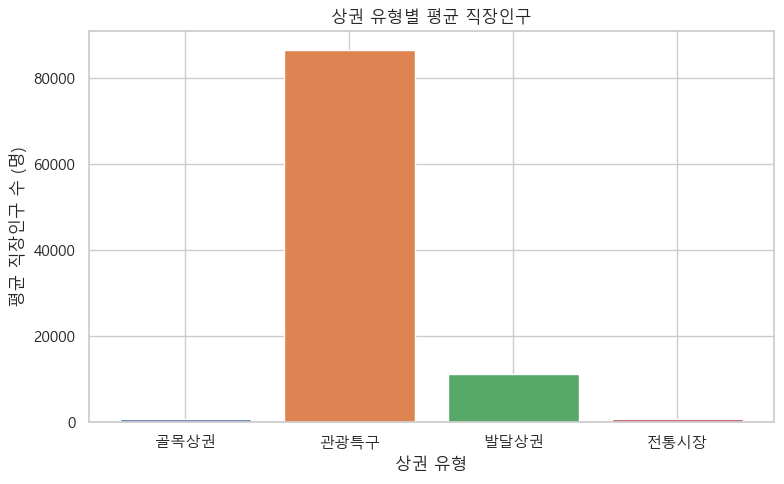

In [147]:
# 상권 유형별 총 직장인구 평균 계산
평균_직장 = df_직장.groupby('상권_구분_코드_명')['총_직장_인구_수'].mean().reset_index()

# 막대 그래프
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(평균_직장['상권_구분_코드_명'], 평균_직장['총_직장_인구_수'],
       color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])

ax.set_title('상권 유형별 평균 직장인구')
ax.set_xlabel('상권 유형')
ax.set_ylabel('평균 직장인구 수 (명)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 상권 유형별 평균 직장인구
- 관광특구: 약 87,000명으로 압도적 1위
- 발달상권: 약 11,000명으로 2위
- 골목상권/전통시장: 매우 낮음
- 관광특구는 대규모 업무지구와 겹치는 경우가 많아 직장인구 집중

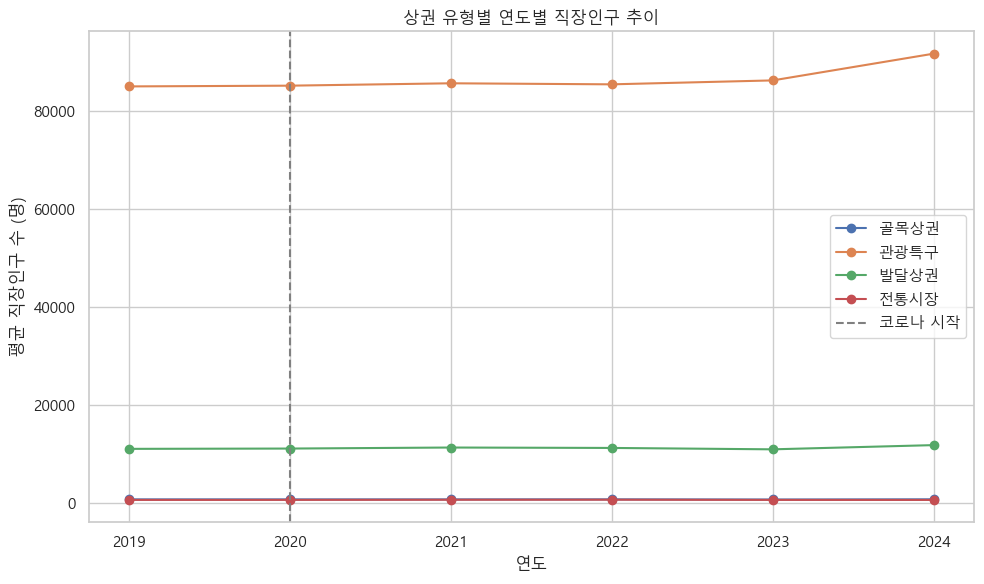

In [148]:
# 연도 컬럼 추가
df_직장['연도'] = df_직장['기준_년분기_코드'].astype(str).str[:4].astype(int)

# 상권 유형별 연도별 평균 직장인구
연도별 = df_직장.groupby(['연도', '상권_구분_코드_명'])['총_직장_인구_수'].mean().reset_index()

# 꺾은선 그래프
fig, ax = plt.subplots(figsize=(10, 6))
for 유형 in 연도별['상권_구분_코드_명'].unique():
    df_유형 = 연도별[연도별['상권_구분_코드_명'] == 유형]
    ax.plot(df_유형['연도'], df_유형['총_직장_인구_수'], marker='o', label=유형)

# 코로나 시점 표시
ax.axvline(x=2020, color='gray', linestyle='--', label='코로나 시작')

ax.set_title('상권 유형별 연도별 직장인구 추이')
ax.set_xlabel('연도')
ax.set_ylabel('평균 직장인구 수 (명)')
ax.legend()
plt.tight_layout()
plt.show()

## 상권 유형별 연도별 직장인구 추이
- 관광특구: 코로나 영향 없이 꾸준히 증가 → 2024년 최고치
- 발달상권: 전체 기간 안정적으로 유지
- 골목상권/전통시장: 직장인구 매우 적음 → 주거/소비 중심 상권
- 전반적으로 직장인구는 코로나 영향을 거의 받지 않음

In [149]:
from pathlib import Path
import zipfile, shutil

current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent

# 경로
target_dir = project_root / 'data' / '07_상주인구'
csv_path = target_dir / '서울시 상권분석서비스(상주인구-상권).csv'

# CSV 없으면 raw에서 zip 찾아서 자동 압축 해제
if not csv_path.exists():
    print('📦 CSV 없음, zip 찾는 중...')
    raw_dir = project_root / 'data' / 'raw'
    
    zip_files = list(raw_dir.glob('*상주인구*.zip'))
    if not zip_files:
        raise FileNotFoundError(f'{raw_dir} 에 상주인구 zip 없음')
    
    zip_path = zip_files[0]
    print(f'  압축 해제: {zip_path.name}')
    target_dir.mkdir(parents=True, exist_ok=True)
    
    with zipfile.ZipFile(zip_path, 'r') as z:
        for info in z.infolist():
            if info.filename.startswith('__MACOSX'):
                continue
            try:
                filename = info.filename.encode('cp437').decode('utf-8')
            except:
                filename = info.filename
            
            if info.is_dir():
                continue
            
            out_path = target_dir / filename
            out_path.parent.mkdir(parents=True, exist_ok=True)
            with z.open(info) as src, open(out_path, 'wb') as dst:
                shutil.copyfileobj(src, dst)
    print(f'  ✅ 완료')

# CSV 로드
df_상주 = pd.read_csv(csv_path, encoding='cp949')
print(f'✅ 상주인구 로드: {df_상주.shape}')

📦 CSV 없음, zip 찾는 중...
  압축 해제: 서울시 상권분석서비스(상주인구-상권).zip
  ✅ 완료
✅ 상주인구 로드: (40812, 29)


In [150]:
from pathlib import Path

current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent

# 상주인구 파일 경로
csv_path = project_root / 'data' / '07_상주인구' / '서울시 상권분석서비스(상주인구-상권).csv'

# 상주인구 데이터 불러오기
df_상주 = pd.read_csv(csv_path, encoding='cp949')
print(f'✅ 상주인구 로드 완료: {df_상주.shape}')

✅ 상주인구 로드 완료: (40812, 29)


In [151]:
# 분석 기간 필터링 (2019~2024)
df_상주 = df_상주[df_상주['기준_년분기_코드'] < 20250]

print("shape:", df_상주.shape)
print("기간:", sorted(df_상주['기준_년분기_코드'].unique()))
print("상권 유형:", df_상주['상권_구분_코드_명'].unique())
print()
print("결측치:")
print(df_상주.isnull().sum())

shape: (34280, 29)
기간: [np.int64(20194), np.int64(20201), np.int64(20202), np.int64(20203), np.int64(20204), np.int64(20211), np.int64(20212), np.int64(20213), np.int64(20214), np.int64(20221), np.int64(20222), np.int64(20223), np.int64(20224), np.int64(20231), np.int64(20232), np.int64(20233), np.int64(20234), np.int64(20241), np.int64(20242), np.int64(20243), np.int64(20244)]
상권 유형: ['관광특구' '전통시장' '발달상권' '골목상권']

결측치:
기준_년분기_코드             0
상권_구분_코드              0
상권_구분_코드_명            0
상권_코드                 0
상권_코드_명               0
총_상주인구_수              0
남성_상주인구_수             0
여성_상주인구_수             0
연령대_10_상주인구_수         0
연령대_20_상주인구_수         0
연령대_30_상주인구_수         0
연령대_40_상주인구_수         0
연령대_50_상주인구_수         0
연령대_60_이상_상주인구_수      0
남성연령대_10_상주인구_수       0
남성연령대_20_상주인구_수       0
남성연령대_30_상주인구_수       0
남성연령대_40_상주인구_수       0
남성연령대_50_상주인구_수       0
남성연령대_60_이상_상주인구_수    0
여성연령대_10_상주인구_수       0
여성연령대_20_상주인구_수       0
여성연령대_30_상주인구_수       0
여성연령대_40_상주인구_수       0


## 상주인구 기본 정보
- 행: 34,280개 / 컬럼: 29개
- 기간: 2019Q4 ~ 2024Q4 (직장인구와 달리 2019Q4부터 시작)
- 상권 유형: 4개 
- 결측치: 없음 

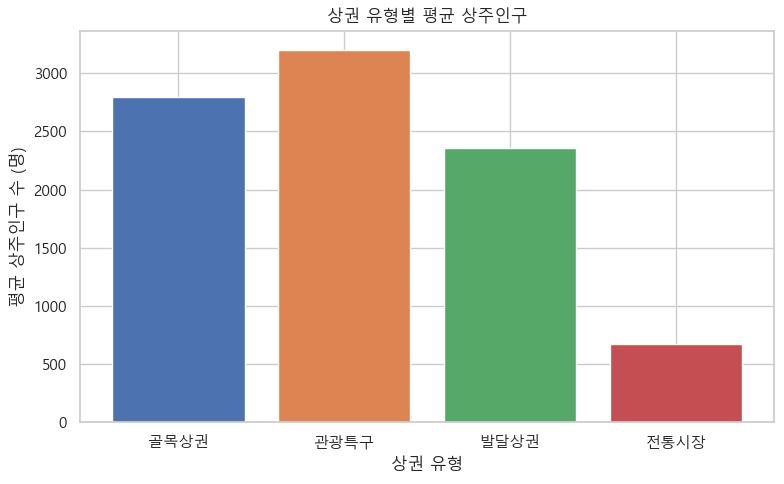

In [152]:
# 상권 유형별 총 상주인구 평균 계산
평균_상주 = df_상주.groupby('상권_구분_코드_명')['총_상주인구_수'].mean().reset_index()

# 막대 그래프
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(평균_상주['상권_구분_코드_명'], 평균_상주['총_상주인구_수'],
       color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])

ax.set_title('상권 유형별 평균 상주인구')
ax.set_xlabel('상권 유형')
ax.set_ylabel('평균 상주인구 수 (명)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 상권 유형별 평균 상주인구
- 관광특구: 약 3,200명으로 1위
- 골목상권: 약 2,800명으로 2위 → 주거 밀집 지역에 분포
- 발달상권: 약 2,350명
- 전통시장: 약 670명으로 가장 낮음
- 직장인구와 달리 유형 간 격차가 크지 않음

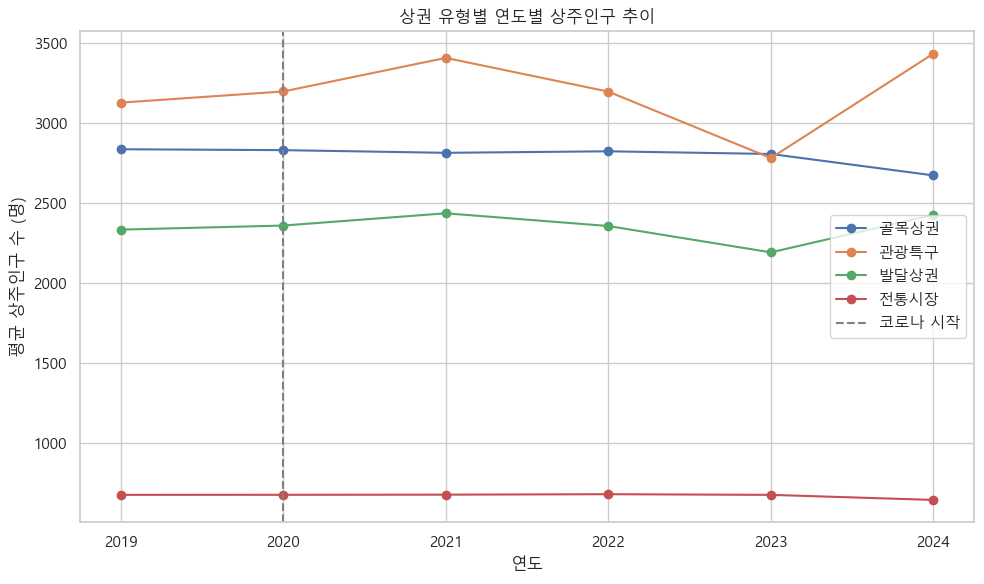

In [153]:
# 연도 컬럼 추가
df_상주['연도'] = df_상주['기준_년분기_코드'].astype(str).str[:4].astype(int)

# 상권 유형별 연도별 평균 상주인구
연도별_상주 = df_상주.groupby(['연도', '상권_구분_코드_명'])['총_상주인구_수'].mean().reset_index()

# 꺾은선 그래프
fig, ax = plt.subplots(figsize=(10, 6))
for 유형 in 연도별_상주['상권_구분_코드_명'].unique():
    df_유형 = 연도별_상주[연도별_상주['상권_구분_코드_명'] == 유형]
    ax.plot(df_유형['연도'], df_유형['총_상주인구_수'], marker='o', label=유형)

# 코로나 시점 표시
ax.axvline(x=2020, color='gray', linestyle='--', label='코로나 시작')

ax.set_title('상권 유형별 연도별 상주인구 추이')
ax.set_xlabel('연도')
ax.set_ylabel('평균 상주인구 수 (명)')
ax.legend()
plt.tight_layout()
plt.show()

## 상권 유형별 연도별 상주인구 추이
- 관광특구: 등락 있으나 전반적으로 가장 높음
- 골목상권: 전체 기간 안정적 유지 → 주거 기반 탄탄
- 발달상권: 2023년 하락 후 2024년 회복
- 전통시장: 전체 기간 가장 낮고 변화 거의 없음
- 상주인구는 직장인구와 달리 코로나 영향 거의 없음